# 层级图：学习、留出诊断与熟悉度算法探针

使用 Restart Kernel and Run All 一次执行全部流程。除耗时的无框检测外，相关开关默认开启；默认恢复已完成的 34 对象检查点并验证重放，避免重复训练。若需独立新池，将 RESUME_CHECKPOINT 设为 None。所有新结果进入新目录，旧输出已备份。

测试划分仅用于固定设置的评价；不要根据 test 结果反复调整参数。分类头为独立对照，弱证据不授权图更新。


In [15]:
import sys, json, copy, random, time, gc, hashlib, importlib
from dataclasses import asdict
from pathlib import Path
from collections import Counter
from datetime import datetime
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/nns').is_dir())
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))
# Run All reloads modules and starts fresh Python graph objects; no stale imported code.
for module in ('local_assignment','graph_memorypool_onceoptimizer','supervised_data','pending_associations',
               'supervised_graph_learning','supervised_readout','experiment_diagnostics',
               'supervised_experiment','familiarity_probe'):
    importlib.reload(importlib.import_module('nns.memorygraphs.'+module))
for name in ('learner','model','encoder','experiment','trainer','batch_rows','caches'):
    globals().pop(name,None)
from nns.memorygraphs.experiment_diagnostics import save_json, json_value
from nns.memorygraphs.familiarity_probe import run_familiarity_pilot, ProbeConfig
from nns.memorygraphs.graph_memorypool_onceoptimizer import MemoryConfig, MultilevelCoordinator, SearchBudget, OnceGraphBuilder, GmemoryI, GmemoryII, advanced_partition_contract
from nns.memorygraphs.supervised_data import AnnotationDataset, SupervisedConfig, ObjectViewTransform
from nns.memorygraphs.supervised_graph_learning import SupervisedGraphOptimizer
from nns.memorygraphs.supervised_readout import FixedCNNEncoder, ClassEvidenceReadout, ClassifierTrainer, ProposalDetector, detection_metrics
from nns.memorygraphs.supervised_experiment import SupervisedExperiment, resource_snapshot
VOC_ROOT = Path('/home/p/code/datasets/VOC2007/VOCdevkit/VOC2007')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ('cat', 'dog', 'car')
EXCLUDE_DIFFICULT = True  # 自定义已知框分类协议；不是 VOC 官方 difficult-aware 检测评价
PARTITION_MODE = 'grad_refined'  # grad_refined / grad_gated / independent / legacy_grad_partition
GRAD_CONTINUITY_THRESHOLD = None  # 默认跟随 tau_grad_coh；仅调整此参数不改变三个模态自身阈值
RUN_PARTITION_COMPARISON = True 
PROFILE_STAGES = True  # CUDA 同步分段计时有额外开销，长期运行可关闭
BATCH_START_IMAGE = 0
RUN_SINGLE_DEMOS = True
RUN_PENDING_MAINTENANCE = True
RUN_FAMILIARITY_PILOT = True
RUN_WEAK_HEAD = True
RUN_RESUME_CHECK = True
PILOT_OBJECT_LIMIT = 3
HEAD_SEEDS = (0, 1, 2)  # 固定对照，不根据 test 选择种子
RUN_WRITE_RECALL_AUDIT = True  # 已知原点仅作诊断，不计作普通检索成功
RUN_MEMORY_BUILD = True  # 默认运行；恢复已完成检查点时，重复来源由账本跳过
RUN_TRAINING_RECALL = True  # 建图完成后冻结图，回查所有本轮已提交对象
RUN_QUERY = True
RUN_HEAD_FIT = True
RUN_DETECTION = False  # 当前先隔离已知框识别问题；需要时手动启用滑窗检测
BATCH_IMAGE_LIMIT = 20   # 原图数，不是目标数；None 使用全部 memory_build
QUERY_IMAGE_LIMIT = 20   # None 查询整个对应留出集；小样本可能缺类
CHECKPOINT_EVERY = 10   # 每多少个标注目标保存一次，0 只在结束/中断时保存
RESUME_CHECKPOINT = root/'results/supervised_graph/voc2007_20260921_231411_853393/memory.pt'
if not RESUME_CHECKPOINT.exists(): RESUME_CHECKPOINT = None
# Existing completed memory is reused by default; set None for an independent fresh training run.
#  # 可填写已有 memory.pt；必须使用完全相同的划分和配置
config = SupervisedConfig()
search_budget = SearchBudget(max_seconds=None, max_template_pairs=None)
OUTPUT = root / 'results/supervised_graph' / datetime.now().strftime('voc2007_%Y%m%d_%H%M%S_%f')
MODALITIES = {0: 'grad', 1: 'RGB', 2: 'curv', 3: 'aps (anisotropy)', 4: 'ori'}
def sync():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize(DEVICE)
torch.set_num_threads(2)
print({'device': str(DEVICE), 'torch': torch.__version__, 'voc_root': str(VOC_ROOT), 'output': str(OUTPUT)})


{'device': 'cuda', 'torch': '2.10.0+cu128', 'voc_root': '/home/p/code/datasets/VOC2007/VOCdevkit/VOC2007', 'output': '/home/p/code/Conscious-linux/Conscious-demo/results/supervised_graph/voc2007_20260923_171046_543975'}


## 1. 官方划分与样本检查

官方 train 只用于 memory_build/readout_fit，官方 val 保留为 validation。test 未解压时保持空集，不拿 val 冒充 test；以后解压 test 后重新执行本节即可识别。所有集合按原图去重。

本演示默认过滤 difficult 目标，保留同图中其他可用目标。这是框分类调试协议；检测 AP 目前仍是简化指标。更改类别时会检查各非空划分的类别覆盖。


In [16]:
class DemoVOCDataset(AnnotationDataset):
    def annotations(self, image_id):
        annotations = super().annotations(image_id)
        return [a for a in annotations if not EXCLUDE_DIFFICULT or a.flags.get('difficult') != '1']

dataset = DemoVOCDataset(VOC_ROOT / 'JPEGImages', VOC_ROOT / 'Annotations',
    coordinate_convention='1based_inclusive', dataset_version='VOC2007')
raw_dataset = AnnotationDataset(VOC_ROOT / 'JPEGImages', VOC_ROOT / 'Annotations',
    coordinate_convention='1based_inclusive', dataset_version='VOC2007')
manifest = dataset.manifest()
classes = tuple(CLASSES)
def official_ids(name, required=True):
    p = VOC_ROOT / 'ImageSets/Main' / f'{name}.txt'
    if not p.exists():
        if required:
            raise FileNotFoundError(p)
        return []
    ids = p.read_text().split()
    missing = [k for k in ids if k not in manifest or not (VOC_ROOT / 'JPEGImages' / f'{k}.jpg').exists()]
    if missing:
        raise RuntimeError(f'{name} 缺少图片/标注: {missing[:10]}')
    return ids
official = {'train': official_ids('train'), 'validation': official_ids('val'), 'test': official_ids('test', False)}
if any(set(official[a]) & set(official[b]) for a,b in (('train','validation'),('train','test'),('validation','test'))):
    raise RuntimeError('官方划分存在原图交叉')
def eligible(ids):
    return [k for k in ids if any(a.class_id in classes for a in manifest[k])]
train_ids = sorted(eligible(official['train']))
random.Random(config.seed).shuffle(train_ids)
cut = round(.75 * len(train_ids))
split_manifest = {'seed': config.seed, 'classes': list(classes), 'dataset': 'VOC2007',
    'exclude_difficult': EXCLUDE_DIFFICULT, 'protocol': 'official_train_internal_75_25_official_val_test',
    'splits': {'memory_build': train_ids[:cut], 'readout_fit': train_ids[cut:],
               'validation': eligible(official['validation']), 'test': eligible(official['test'])}}
summary = []
for split, ids in split_manifest['splits'].items():
    counts = Counter(a.class_id for k in ids for a in manifest[k] if a.class_id in classes)
    if ids and set(classes) - set(counts):
        raise ValueError(f'{split} 类别覆盖不足: {set(classes)-set(counts)}')
    summary.append({'split': split, 'images': len(ids), 'objects': sum(counts.values()), **dict(counts)})
display(pd.DataFrame(summary).fillna(0))
if not split_manifest['splits']['test']:
    print('当前 VOC_ROOT 下没有 test 划分；请核对数据目录，test 评价会跳过。')


,split,images,objects,dog,car,cat
0,memory_build,549,806,183,488,135
1,readout_fit,183,258,70,137,51
2,validation,723,1072,257,625,190
3,test,1441,2048,489,1201,358


## 2. 从建图集合选两张不同原图

优先取同一类别，以观察第二张图是否复用第一张图的实体；每图取该类别面积最大的非 difficult 目标。选择依据只有标注和面积，不依赖模型成绩。不足两张时明确报错。展示图中红框是当前目标，灰框是同图其他标注目标。


{'image_id': '007530', 'bbox': (182.0, 60.0, 326.0, 167.0), 'round_trip': (182.0, 60.0, 326.0, 167.0)}
{'image_id': '000209', 'bbox': (13.0, 75.0, 400.0, 375.0), 'round_trip': (13.0, 75.00000000000001, 400.0, 375.0)}


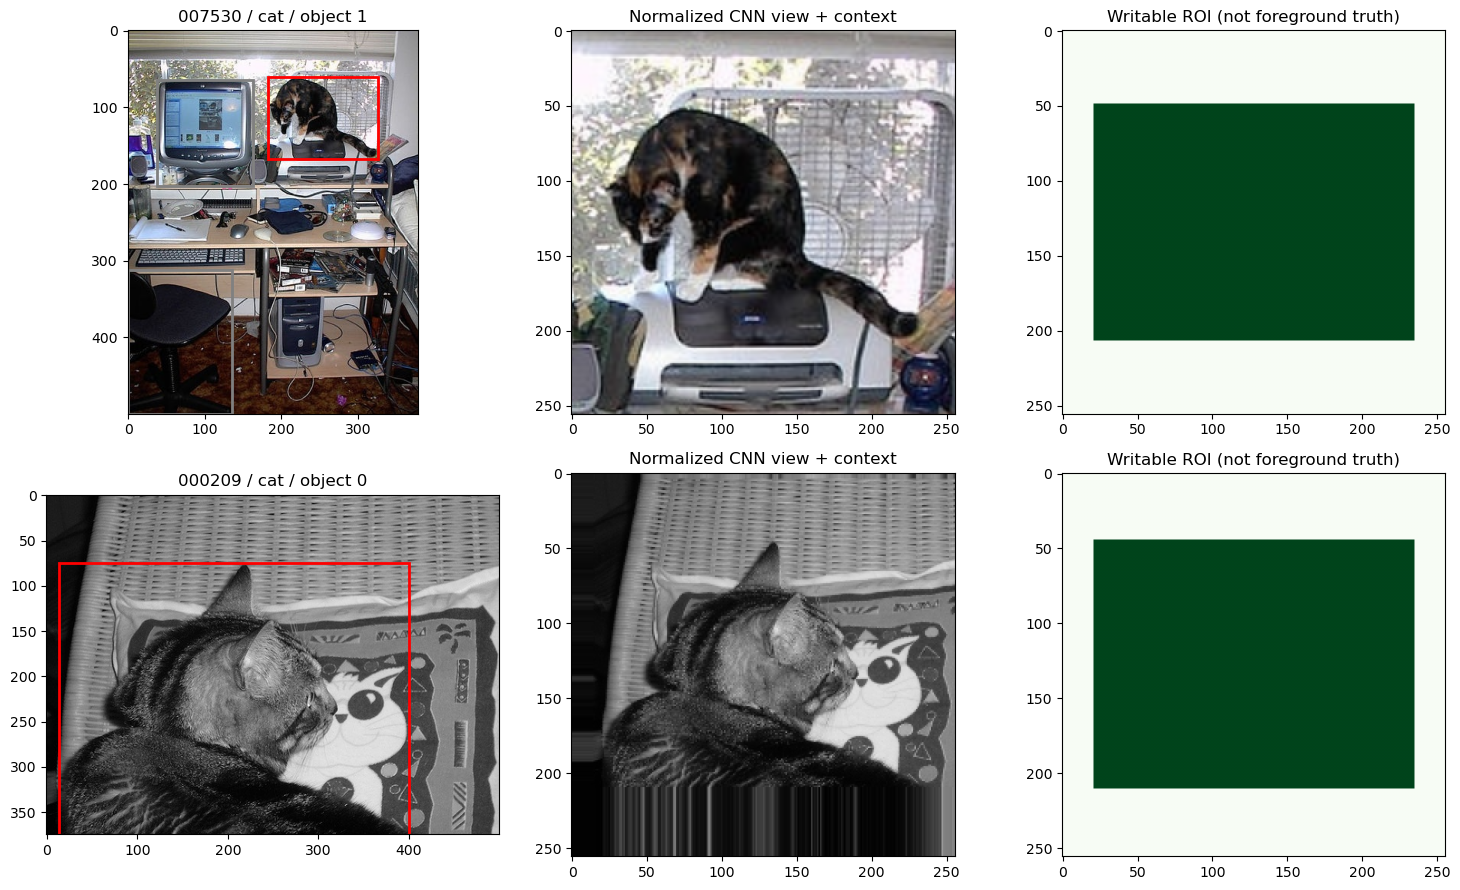

In [17]:
demo_annotations = []
for label in classes:
    candidates = []
    for image_id in split_manifest['splits']['memory_build']:
        objects = [a for a in manifest[image_id] if a.class_id == label]
        if objects:
            candidates.append(max(objects, key=lambda a: (a.bbox[2]-a.bbox[0])*(a.bbox[3]-a.bbox[1])))
    if len(candidates) >= 2:
        demo_annotations = candidates[:2]
        break
if len(demo_annotations) != 2:
    raise RuntimeError('memory_build 中没有可用于同类两图演示的类别')
transform = ObjectViewTransform(config)
def load_observation(annotation):
    image, _ = dataset.load_image_objects(annotation.image_id)
    # 即使 difficult 不参与学习，其框仍用于单图演示的归属不确定性标记。
    others = raw_dataset.annotations(annotation.image_id)
    observation = transform.make_view(image, annotation,
        other_boxes=[a.bbox for a in others if a.object_id != annotation.object_id])
    return image, observation, others

demo_inputs = []
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, annotation in enumerate(demo_annotations):
    image, observation, others = load_observation(annotation)
    demo_inputs.append((annotation, observation))
    axes[i,0].imshow(image[0].permute(1,2,0))
    for a in others:
        x0,y0,x1,y1 = a.bbox
        axes[i,0].add_patch(Rectangle((x0,y0),x1-x0,y1-y0,fill=False,
            edgecolor='red' if a.object_id == annotation.object_id else 'gray',linewidth=2))
    axes[i,0].set_title(f'{annotation.image_id} / {annotation.class_id} / object {annotation.object_id}')
    axes[i,1].imshow(observation.view_tensor[0].permute(1,2,0))
    axes[i,1].set_title('Normalized CNN view + context')
    axes[i,2].imshow(observation.valid_mask.cpu(),cmap='Greens',vmin=0,vmax=1)
    axes[i,2].set_title('Writable ROI (not foreground truth)')
    print({'image_id': annotation.image_id, 'bbox': annotation.bbox,
           'round_trip': observation.box_to_original(observation.canonical_box)})
plt.tight_layout()
plt.show()


## 3. 初始化与调试工具

默认 grad_refined，图中标注属性的 grad 来源。演示池与批量池分开；真实合同与源码摘要保存至运行目录。


In [18]:
def gate_audit(report, cfg):
    rows=[]
    for mid in (2,3,4):
        support=report.supports.get(mid)
        if support is None: continue
        allowed=support.gate_context.get('grad_eligible')
        regions=[r for r in report.regions if r.modality_id==mid]
        sampled=[p for r in regions for p in r.samples]
        independent=advanced_partition_contract(cfg)['mode']=='grad_gated'
        row={'modality':MODALITIES[mid],'own_gate_pixels':int(support.gate_context.get('own_gate_before_grad',support.writable).sum()),
             'grad_eligible':int(allowed.sum()) if allowed is not None else None,
             'writable':int(support.writable.sum()),'active':int(support.support.sum()),
             'regions':len(regions),'samples':len(sampled),
             'inherited_regions':sum(r.parent_region_id is not None for r in regions)}
        if independent:
            outside=~allowed.astype(bool)
            row['gate_violations']=int((support.writable & outside).sum())+sum(bool(outside.flat[p]) for p in sampled)
            assert row['gate_violations']==0, '门控外存在可写/采样点'
            assert all(not outside.flat[p] for r in regions for p in r.pixels), '区域跨出 grad 门控'
            assert row['inherited_regions']==0, '新模式不应复制 grad 分区'
        if advanced_partition_contract(cfg)['mode']=='grad_refined':
            row['parent_violations']=sum(int(np.count_nonzero(report.labels[0].flat[r.pixels] != r.support_parent_region_id)) for r in regions)
            assert row['parent_violations']==0, '属性越出所属 grad 父域'
        rows.append(row)
    return rows

def audit_memory(learner):
    model=learner.model
    broken=[(eid,role) for eid,e in model.gmem_iii.entity_nodes.items()
        for role,m in e.component_edges.items() if m['sem_id'] not in model.gmem_ii.semantic_nodes]
    nonfinite=[nid for nid,node in model.gmem_i.nodes.items() if not torch.isfinite(node.prototype).all()]
    bad_ledger=[k for k,v in learner.ledger.items() if v['entity_id'] not in model.gmem_iii.entity_nodes]
    assert not broken and not nonfinite and not bad_ledger, (broken,nonfinite,bad_ledger)
    patterns=Counter(tuple(sorted({model.gmem_i.nodes[model.gmem_ii.semantic_nodes[m['sem_id']].anchor_id].modality_id
        for m in e.component_edges.values()})) for e in model.gmem_iii.entity_nodes.values())
    return {'broken_roles':len(broken),'nonfinite_prototypes':len(nonfinite),'bad_ledger':len(bad_ledger),
        'modality_patterns':dict(patterns),'visually_confirmed':sum((e.supervision or {}).get('visually_confirmed',False)
            for e in model.gmem_iii.entity_nodes.values())}

def new_system(partition_mode=PARTITION_MODE):
    cfg = MemoryConfig()
    for name in dir(cfg):
        value = getattr(cfg, name)
        if isinstance(value, (dict, list, set)):
            setattr(cfg, name, copy.deepcopy(value))
    cfg.once_bind_edge_attributes = partition_mode == 'legacy_grad_partition'
    cfg.once_advanced_partition_mode = 'independent' if cfg.once_bind_edge_attributes else partition_mode
    cfg.once_advanced_grad_continuity = GRAD_CONTINUITY_THRESHOLD
    cfg.device = DEVICE
    cfg.H = cfg.W = config.view_size
    encoder = FixedCNNEncoder(cfg, config)
    model = MultilevelCoordinator(cfg)
    learner = SupervisedGraphOptimizer(model, classes, config)
    assert advanced_partition_contract(cfg)['mode'] == partition_mode
    print('segmentation contract:', advanced_partition_contract(cfg))
    OUTPUT.mkdir(parents=True,exist_ok=True)
    sources=['src/nns/memorygraphs/'+name+'.py' for name in (
        'local_assignment','graph_memorypool_onceoptimizer','supervised_graph_learning','supervised_data','supervised_readout',
        'pending_associations','supervised_experiment','experiment_diagnostics','familiarity_probe')]
    manifest={'torch':torch.__version__,'device':str(DEVICE),'voc_root':str(VOC_ROOT),
        'partition':advanced_partition_contract(cfg),'supervised_config':asdict(config),
        'source_sha256':{name:hashlib.sha256((root/name).read_bytes()).hexdigest() for name in sources},
        'memory_config':{k:getattr(cfg,k) for k in dir(cfg) if not k.startswith('_') and not callable(getattr(cfg,k))},
        'run_id':OUTPUT.name,'switches':{k:globals()[k] for k in globals() if k.startswith('RUN_')},
        'notebook_source_sha256':hashlib.sha256(json.dumps([c['source'] for c in json.loads((root/'src/test_supervised_graph_learning.ipynb').read_text())['cells'] if c['cell_type']=='code'],ensure_ascii=False).encode()).hexdigest()}
    (OUTPUT/'run_contract.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2,default=str))
    return cfg, encoder, model, learner

def graph_counts(model):
    return {'GmemI': len(model.gmem_i.nodes), 'GmemII': len(model.gmem_ii.semantic_nodes),
            'GmemIII': len(model.gmem_iii.entity_nodes)}

def entity_rows(model):
    return [{'entity': eid, 'label': (e.supervision or {}).get('label_id'), 'status': e.status,
             'members': len(e.component_edges), 'support': e.evidence.support,
             'annotation_confirmed': (e.supervision or {}).get('confirmation'),
             'visually_confirmed': (e.supervision or {}).get('visually_confirmed', False),
             'reuse_unresolved': (e.supervision or {}).get('reuse_unresolved', False)}
            for eid,e in model.gmem_iii.entity_nodes.items()]

def show_regions(debug):
    if debug is None:
        print('本次没有构图快照（例如已处理的标注直接返回）。')
        return
    report = debug['report']
    selected = set(debug['selected_ids'])
    fig, axes = plt.subplots(1,5,figsize=(20,4))
    cmap = copy.copy(plt.get_cmap('tab20')); cmap.set_bad('black')
    for mid,ax in enumerate(axes):
        labels = report.labels.get(mid)
        if labels is None:
            ax.set_title(f'{MODALITIES[mid]}: missing'); ax.axis('off'); continue
        ax.imshow(np.ma.masked_where(labels < 0, labels),cmap=cmap,interpolation='nearest')
        for r in report.regions:
            if r.modality_id == mid and r.region_id in selected and r.anchor is not None:
                y,x = divmod(r.anchor, report.shape[1])
                ax.scatter(x,y,marker='*',s=65,c='white',edgecolors='black')
                parent = r.support_parent_region_id if r.support_parent_region_id is not None else r.parent_region_id
                text = str(r.region_id) + (f'←grad {parent}' if parent is not None else '')
                ax.text(x+2,y+2,text,fontsize=7,color='white',bbox=dict(facecolor='black',alpha=.5,pad=1))
        ax.set_title(f'{MODALITIES[mid]} / selected anchors'); ax.axis('off')
    plt.tight_layout(); plt.show()
    display(pd.DataFrame([{'region':r.region_id,'modality':MODALITIES[r.modality_id],
        'parent_grad':r.parent_region_id,'support_parent':r.support_parent_region_id,'completed':r.completed,'pixels':len(r.pixels),'samples':len(r.samples),
        'selected':r.region_id in selected,'truncated':r.budget_truncated,
        'reason':debug['selection']['rejected'].get(r.region_id, ', '.join(r.reasons))}
        for r in report.regions]))
    display(pd.DataFrame([{'region':rid, **values} for rid,values in debug['selection'].get('quality_components',{}).items() if rid in selected]))
    print('构图:', report.summary())
    display(pd.DataFrame(gate_audit(report, demo_cfg)))
    print('成员选择:', {k:v for k,v in debug['selection'].items() if k not in ('quality','quality_components')})

def show_entity(model, eid):
    if eid not in model.gmem_iii.entity_nodes:
        return
    e = model.gmem_iii.entity_nodes[eid]
    fig,ax = plt.subplots(figsize=(6,5))
    for role,m in e.component_edges.items():
        mid = model.gmem_i.nodes[model.gmem_ii.semantic_nodes[m['sem_id']].anchor_id].modality_id
        ax.plot([0,m['dx']],[0,m['dy']],color='lightgray',zorder=0)
        ax.scatter(m['dx'],m['dy'],color=plt.get_cmap('tab10')(mid),s=80)
        ax.annotate(f'{role}:{MODALITIES[mid]} / II={m["sem_id"]}',(m['dx'],m['dy']),xytext=(4,4),textcoords='offset points',fontsize=8)
    ax.scatter(0,0,marker='*',s=180,facecolors='none',edgecolors='black',label='root')
    ax.invert_yaxis(); ax.set_aspect('equal',adjustable='datalim'); ax.legend()
    ax.set_title(f'GmemIII {eid}: member anchors relative to root')
    ax.set_xlabel('dx / view pixels'); ax.set_ylabel('dy / view pixels')
    plt.show()

def query_debug(learner, features, observation, title):
    sync(); started=time.perf_counter()
    query = learner.model.query_hierarchy(features,valid_mask=observation.valid_mask,exact=False,trace=True)
    readout = ClassEvidenceReadout(classes,config)
    encoded = readout.encode(query,learner.model,learner.graph_version)
    prediction = readout.predict(encoded,learner.model,observation)
    sync()
    print(title, {'seconds':time.perf_counter()-started, **prediction})
    print('search audit:', {k:query.diagnostics.get(k) for k in ('mode','search_complete',
        'assignment_search_complete','feature_events','event_budget_dropped','region_pose_pruned_or_dropped',
        'entity_pose_pruned_or_dropped','candidate_budget_dropped','geometry_evaluations','structural_fallback')})
    display(pd.DataFrame([{'entity':m.template_id,'score':m.score,'coverage':m.matched_coverage,
        'evaluable':m.evaluable_coverage,'geometry_error':m.geometry_error,'point':m.point}
        for m in query.entities[:10]]))
    return prediction

demo_cfg, demo_encoder, demo_model, demo_learner = new_system()
demo_results = []


segmentation contract: {'mode': 'grad_refined', 'grad_continuity_threshold': 0.6, 'version': 4}


## 3A. 分区模式对照

默认 grad_refined：属性只在已保留的 grad 父域拓扑内细分；其他模式用于消融。统计表不适用项不代表 CNN 数值异常。


In [19]:
if RUN_PARTITION_COMPARISON:
    annotation,observation=demo_inputs[0]
    features=demo_encoder(observation)
    comparisons=[]
    for mode in ('grad_refined','grad_gated','independent','legacy_grad_partition'):
        cfg=copy.deepcopy(demo_cfg)
        cfg.once_bind_edge_attributes=mode=='legacy_grad_partition'
        cfg.once_advanced_partition_mode='independent' if cfg.once_bind_edge_attributes else mode
        sync(); started=time.perf_counter()
        report=OnceGraphBuilder(cfg).build_once(features,GmemoryI(),GmemoryII(cfg),valid_mask=observation.valid_mask)
        sync()
        comparisons.extend({'mode':mode,'build_seconds':time.perf_counter()-started,**row} for row in gate_audit(report,cfg))
    display(pd.DataFrame(comparisons))
    del report,features
else:
    print('分区对照未运行；设置 RUN_PARTITION_COMPARISON=True 后执行此格。')


,mode,build_seconds,modality,own_gate_pixels,grad_eligible,writable,active,regions,samples,inherited_regions,parent_violations,gate_violations
0,grad_refined,1.253406,curv,29097,19192.0,1354,1354,52,263,0,0.0,NaN
1,grad_refined,1.253408,aps (anisotropy),33812,19192.0,1354,1354,52,428,0,0.0,NaN
2,grad_refined,1.253409,ori,32794,19192.0,1353,1353,52,661,0,0.0,NaN
3,grad_gated,2.122414,curv,29097,19192.0,16676,15855,51,523,0,NaN,0.0
4,grad_gated,2.122416,aps (anisotropy),33812,19192.0,19192,17283,51,489,0,NaN,0.0
5,grad_gated,2.122417,ori,32794,19192.0,19100,19094,51,1024,0,NaN,0.0
6,independent,2.356036,curv,29097,NaN,29097,18792,51,388,0,NaN,NaN
7,independent,2.356038,aps (anisotropy),33812,NaN,33812,4560,46,137,0,NaN,NaN
8,independent,2.356038,ori,32794,NaN,32794,32774,56,1024,0,NaN,NaN
9,legacy_grad_partition,1.566989,curv,29097,NaN,29097,18792,50,351,0,NaN,NaN


## 4. 图片一：特征 → 分割 → 标注实体 → 原图自检

打印五模态有限值比例及数值范围，检查 NaN/Inf；展示实际区域和入选锚点。写入失败时同样显示分割报告与原因。写入后重放相同标注，检查节点数及独立支持是否保持不变。


开始单图 1: 007530


,modality,shape,finite_fraction,nan,inf,min,max
0,grad,"(1, 4, 256, 256)",1.0,0,0,-11.392431,11.858115
1,RGB,"(1, 3, 256, 256)",1.0,0,0,0.000077,1.000000
2,curv,"(1, 3, 256, 256)",1.0,0,0,0.000026,1.000000
3,aps (anisotropy),"(1, 3, 256, 256)",1.0,0,0,-1.000000,1.000000
4,ori,"(1, 6, 256, 256)",1.0,0,0,-1.570796,1.570796


学习前检索（第二图时用于观察跨图响应） {'seconds': 0.0033301679650321603, 'rejection_reason': 'no_accepted_entity', 'status': 'UNKNOWN', 'class_id': None, 'scores': {'cat': 0.0, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.0), ('dog', 0.0), ('car', 0.0)], 'entity_id': None, 'point': None, 'bbox': None, 'search_complete': True, 'assignment_search_complete': True, 'absence_proven': True, 'graph_version': 0}
search audit: {'mode': 'empty', 'search_complete': True, 'assignment_search_complete': None, 'feature_events': None, 'event_budget_dropped': None, 'region_pose_pruned_or_dropped': None, 'entity_pose_pruned_or_dropped': None, 'candidate_budget_dropped': None, 'geometry_evaluations': None, 'structural_fallback': None}


""


学习结果: {'status': 'ANNOTATED_SEED_CREATED', 'graph_version': 1, 'seconds': 1.4758230269653723, 'stage_seconds': {'validation': 0.00022379099391400814, 'observation_build': 1.2004331239731982, 'selection': 0.011164046009071171, 'region_matching': 0.006033007055521011, 'entity_matching': 1.943204551935196e-05, 'pool_copy': 0.0001440409105271101, 'update_and_commit': 0.03896715305745602, 'write_validation': 0.21883720497135073}, 'profile_synchronized': True, 'modality_counts': {0: {'writable': 11357, 'support': 4793, 'regions': 52, 'selected': 4, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 11357}, 1: {'writable': 33807, 'support': 33807, 'regions': 48, 'selected': 2, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 33807}, 2: {'writable': 1354, 'support': 1354, 'regions': 52, 'selected': 7, 'truncated_regions': 0, 'grad_eligible': 19192, 'own_gate_before_grad': 29097}, 3: {'writable': 1354, 'support': 1354, 'regions': 52, 'selected': 7, 'truncated

,stage,seconds
0,validation,0.000224
1,observation_build,1.200433
2,selection,0.011164
3,region_matching,0.006033
4,entity_matching,0.000019
5,pool_copy,0.000144
6,update_and_commit,0.038967
7,write_validation,0.218837


,writable,support,regions,selected,truncated_regions,grad_eligible,own_gate_before_grad
modality,,,,,,,
0,11357,4793,52,4,0,0,11357
1,33807,33807,48,2,0,0,33807
2,1354,1354,52,7,0,19192,29097
3,1354,1354,52,7,0,19192,33812
4,1353,1353,52,4,0,19192,32794


,stage,GmemI,GmemII,GmemIII
0,before,0,0,0
1,after,321,24,1


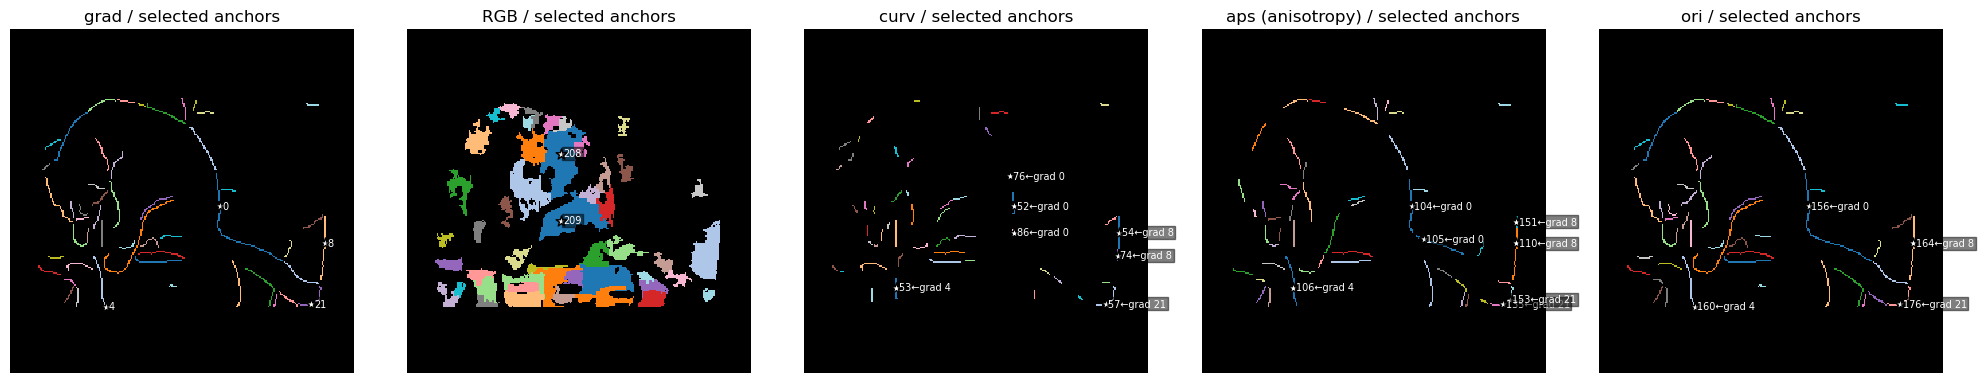

,region,modality,parent_grad,support_parent,completed,pixels,samples,selected,truncated,reason
0,0,grad,None,NaN,True,101,45,True,False,branched_curve_paths
1,1,grad,None,NaN,True,38,15,False,False,selection_budget
2,2,grad,None,NaN,True,50,29,False,False,selection_budget
3,3,grad,None,NaN,True,35,27,False,False,selection_budget
4,4,grad,None,NaN,True,42,20,True,False,branched_curve_paths
...,...,...,...,...,...,...,...,...,...,...
251,251,RGB,None,NaN,True,66,5,False,False,selection_budget
252,252,RGB,None,NaN,True,65,4,False,False,selection_budget
253,253,RGB,None,NaN,True,65,3,False,False,selection_budget
254,254,RGB,None,NaN,True,64,4,False,False,selection_budget


,region,foreground,geometry,sampling,completed
0,0,1.0,1.0,1.0,True
1,4,1.0,1.0,1.0,True
2,8,1.0,1.0,1.0,True
3,21,1.0,1.0,1.0,True
4,52,1.0,1.0,1.0,True
5,53,1.0,1.0,1.0,True
6,54,1.0,1.0,1.0,True
7,57,1.0,1.0,1.0,True
8,74,1.0,1.0,1.0,True
9,76,1.0,1.0,1.0,True


构图: {'build_id': 1, 'shape': (256, 256), 'regions': 256, 'sample_instances': 2424, 'referenced_nodes': 2424, 'region_containers': 256, 'contact_containers': 1024, 'edge_attribute_regions': 0, 'completed_regions': 256, 'truncated_regions': 0, 'edge_observations': 3192, 'rejected': {'nonfinite_pixels': 0, 'advanced_grad_gate_2': 12421, 'advanced_grad_gate_3': 14620, 'advanced_grad_gate_4': 13694, 'local_similarity': 59542, 'direction_conflict': 269, 'junction_connections': 94, 'region_budget': 529, 'small_region': 20402, 'refinement_attribute_discontinuity_2': 681, 'refinement_attribute_discontinuity_3': 321, 'refinement_attribute_discontinuity_4': 13, 'surface_barrier': 30346, 'region_range': 2425, 'contact_pair_budget': 1, 'contact_budget': 583}, 'timings': {'supports': 0.06669656396843493, 'regions': 0.27858680998906493, 'contacts': 0.24480165599379689, 'sampling': 0.13043099199421704, 'writing': 0.4794289080891758, 'total': 1.2003470719791949}, 'warnings': []}


,modality,own_gate_pixels,grad_eligible,writable,active,regions,samples,inherited_regions,parent_violations
0,curv,29097,19192,1354,1354,52,263,0,0
1,aps (anisotropy),33812,19192,1354,1354,52,428,0,0
2,ori,32794,19192,1353,1353,52,661,0,0


成员选择: {'selected_leaves': 321, 'rejected': {35: 'selection_budget', 60: 'parent_selection_budget', 143: 'parent_selection_budget', 199: 'parent_selection_budget', 9: 'selection_budget', 70: 'parent_selection_budget', 109: 'parent_selection_budget', 165: 'parent_selection_budget', 5: 'selection_budget', 73: 'parent_selection_budget', 108: 'parent_selection_budget', 161: 'parent_selection_budget', 11: 'selection_budget', 112: 'parent_selection_budget', 168: 'parent_selection_budget', 2: 'selection_budget', 72: 'parent_selection_budget', 90: 'parent_selection_budget', 94: 'parent_selection_budget', 111: 'parent_selection_budget', 158: 'parent_selection_budget', 214: 'selection_budget', 10: 'selection_budget', 80: 'parent_selection_budget', 119: 'parent_selection_budget', 138: 'parent_selection_budget', 166: 'parent_selection_budget', 13: 'selection_budget', 113: 'parent_selection_budget', 169: 'parent_selection_budget', 217: 'selection_budget', 219: 'selection_budget', 45: 'selection_budg

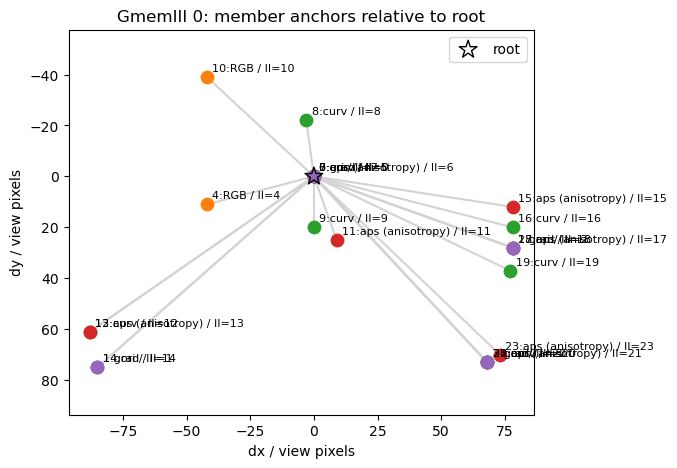

,entity,label,status,members,support,annotation_confirmed,visually_confirmed,reuse_unresolved
0,0,cat,stable,24,1.0,annotation_confirmed,False,False


学习后原图自检（非泛化成绩） {'seconds': 3.6651989289093763, 'rejection_reason': None, 'status': 'PREDICTED', 'class_id': 'cat', 'scores': {'cat': 0.9999942779541016, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.9999942779541016), ('dog', 0.0), ('car', 0.0)], 'entity_id': 0, 'point': (np.float64(156.0), np.float64(131.00000000000003)), 'bbox': (182.0, 60.00000000000002, 326.0, 167.0), 'search_complete': False, 'assignment_search_complete': False, 'absence_proven': False, 'graph_version': 1}
search audit: {'mode': 'sparse_translation', 'search_complete': False, 'assignment_search_complete': False, 'feature_events': 18966, 'event_budget_dropped': 49240, 'region_pose_pruned_or_dropped': 4382, 'entity_pose_pruned_or_dropped': 0, 'candidate_budget_dropped': 64, 'geometry_evaluations': 1374, 'structural_fallback': True}


,entity,score,coverage,evaluable,geometry_error,point
0,0,0.999994,1.0,1.0,2.009718e-14,"(156.0, 131.00000000000003)"


普通检索是否找到刚写入实体: True
已知写入原点精验（仅用于定位故障）:


,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons,assignment_diagnostics
0,0,3,"(156.0, 131.0)",0.999994,1.0,1.0,2.009718e-14,True,321,321,0x1fffffffffffffffffffffffffffffffffffffffffff...,0x1fffffffffffffffffffffffffffffffffffffffffff...,1,[],{}


,role,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons,assignment_diagnostics
0,0,0,2,"(156.0, 131.0)",1.000000,1.0,1.0,2.009718e-14,True,45,45,0x1fffffffffff,0x1fffffffffff,1,[],{}
1,1,1,2,"(71.0, 206.0)",0.999996,1.0,1.0,7.944109e-15,True,20,20,0xfffff,0xfffff,1,[],{}
2,2,2,2,"(234.0, 159.0)",0.999989,1.0,1.0,3.757863e-15,True,16,16,0xffff,0xffff,1,[],{}
3,3,3,2,"(224.0, 204.0)",0.999998,1.0,1.0,2.512148e-15,True,17,17,0x1ffff,0x1ffff,1,[],{}
4,4,4,2,"(114.0, 142.0)",1.000000,1.0,1.0,7.324107e-15,True,18,18,0x3ffff,0x3ffff,1,[],{}
5,5,5,2,"(156.0, 131.0)",1.000000,1.0,1.0,2.666847e-15,True,6,6,0x3f,0x3f,1,[],{}
6,6,6,2,"(156.0, 131.0)",1.000000,1.0,1.0,3.757863e-15,True,15,15,0x7fff,0x7fff,1,[],{}
7,7,7,2,"(156.0, 131.0)",0.999998,1.0,1.0,1.421085e-14,True,35,35,0x7ffffffff,0x7ffffffff,1,[],{}
8,8,8,2,"(153.0, 109.0)",0.999998,1.0,1.0,1.224647e-16,True,3,3,0x7,0x7,1,[],{}
9,9,9,2,"(156.0, 151.0)",1.000000,1.0,1.0,2.220446e-16,True,3,3,0x7,0x7,1,[],{}


,level,template_id,candidates,accepted,best
0,2,15,58,22,"{'point': (234.0, 143.0), 'score': 0.999984741..."
1,2,19,58,17,"{'point': (233.0, 168.0), 'score': 0.999984741..."
2,2,9,58,6,"{'point': (156.0, 151.0), 'score': 1.0, 'evalu..."
3,2,8,58,1,"{'point': (153.0, 109.0), 'score': 0.999998271..."
4,2,12,58,2,"{'point': (68.0, 192.0), 'score': 0.9999960935..."
5,2,3,57,6,"{'point': (224.0, 204.0), 'score': 0.999997825..."
6,2,21,58,11,"{'point': (224.0, 204.0), 'score': 0.999980401..."
7,2,6,57,2,"{'point': (156.0, 131.0), 'score': 0.999999953..."
8,2,5,57,1,"{'point': (156.0, 131.0), 'score': 0.999999797..."
9,2,23,58,7,"{'point': (229.0, 201.0), 'score': 0.999983804..."


重复观察: {'status': 'ALREADY_OBSERVED', 'nodes_unchanged': True, 'support_unchanged': True}


,image_id,class,status,encoder_seconds,learn_seconds,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,007530,cat,ANNOTATED_SEED_CREATED,0.003479,1.479573,321,24,1,3521822720,3242688512,36115968,106954752,239186944


In [20]:
def run_single_demo(index):
    annotation, observation = demo_inputs[index]
    print(f'开始单图 {index+1}: {annotation.image_id}', flush=True)
    sync(); started = time.perf_counter()
    features = demo_encoder(observation)
    sync(); encoded_at = time.perf_counter()
    feature_rows=[]
    for mid,value in features.items():
        finite=torch.isfinite(value); values=value[finite]
        feature_rows.append({'modality':MODALITIES[mid],'shape':tuple(value.shape),
            'finite_fraction':float(finite.float().mean()),'nan':int(torch.isnan(value).sum()),
            'inf':int(torch.isinf(value).sum()),'min':float(values.min()) if values.numel() else None,
            'max':float(values.max()) if values.numel() else None})
    display(pd.DataFrame(feature_rows))
    before = graph_counts(demo_model)
    query_debug(demo_learner, features, observation, '学习前检索（第二图时用于观察跨图响应）')
    sync(); learn_start=time.perf_counter()
    result = demo_learner.learn_object(observation,features,search_budget=search_budget,capture_debug=True,profile_stages=PROFILE_STAGES)
    sync(); learn_seconds=time.perf_counter()-learn_start
    debug=demo_learner.last_debug
    print('学习结果:', result)
    display(pd.DataFrame([{'stage':k,'seconds':v} for k,v in result.get('stage_seconds',{}).items()]))
    display(pd.DataFrame.from_dict(result.get('modality_counts',{}),orient='index').rename_axis('modality'))
    display(pd.DataFrame([{'stage':'before',**before},{'stage':'after',**graph_counts(demo_model)}]))
    show_regions(debug)
    show_entity(demo_model,result.get('entity_id'))
    display(pd.DataFrame(entity_rows(demo_model)))
    prediction=query_debug(demo_learner,features,observation,'学习后原图自检（非泛化成绩）')
    if RUN_WRITE_RECALL_AUDIT and debug and 'write_witness' in debug:
        audit=demo_learner.diagnose_write_recall(observation,features,debug['write_witness'])
        print('普通检索是否找到刚写入实体:',audit['ordinary_target_hit'])
        print('已知写入原点精验（仅用于定位故障）:')
        display(pd.DataFrame(audit['known_pose_entity']))
        display(pd.DataFrame(audit['known_pose_regions']))
        display(pd.DataFrame(audit['query']['trace']))
        OUTPUT.mkdir(parents=True,exist_ok=True)
        (OUTPUT/f'demo_{annotation.image_id}_recall.json').write_text(json.dumps(audit,ensure_ascii=False,indent=2,default=str))
    counts_before_repeat=graph_counts(demo_model)
    support_before={eid:e.evidence.support for eid,e in demo_model.gmem_iii.entity_nodes.items()}
    if result['status'] in ('MATCHED_UPDATED','ANNOTATED_SEED_CREATED','ALREADY_OBSERVED'):
        replay=demo_learner.learn_object(observation,features,search_budget=search_budget)
        print('重复观察:', {'status':replay['status'],
            'nodes_unchanged':counts_before_repeat==graph_counts(demo_model),
            'support_unchanged':support_before=={eid:e.evidence.support for eid,e in demo_model.gmem_iii.entity_nodes.items()}})
    else:
        print('本次未提交，跳过重复构图；先检查状态与分割原因。')
    row={'image_id':annotation.image_id,'class':annotation.class_id,'status':result['status'],
         'encoder_seconds':encoded_at-started,'learn_seconds':learn_seconds,
         **graph_counts(demo_model),**resource_snapshot(DEVICE)}
    demo_results.append(row)
    display(pd.DataFrame([row]))
    demo_learner.last_debug=None
    return prediction

if RUN_SINGLE_DEMOS:
    demo_prediction_1 = run_single_demo(0)
else:
    print('两张单图演示已关闭。')


## 5. 图片二：沿用第一张的记忆

第二张来自不同原图、同一类别。学习前的响应更有助于观察跨图检索，学习后重点看 MATCHED_UPDATED / ANNOTATED_SEED_CREATED / UNRESOLVED 及其原因。不同姿态允许建立新实体，不强求两张图合并。


开始单图 2: 000209


,modality,shape,finite_fraction,nan,inf,min,max
0,grad,"(1, 4, 256, 256)",1.0,0,0,-10.022427,10.025043
1,RGB,"(1, 3, 256, 256)",1.0,0,0,0.000138,0.907906
2,curv,"(1, 3, 256, 256)",1.0,0,0,0.000000,1.000000
3,aps (anisotropy),"(1, 3, 256, 256)",1.0,0,0,-1.000000,1.000000
4,ori,"(1, 6, 256, 256)",1.0,0,0,-1.570796,1.570796


学习前检索（第二图时用于观察跨图响应） {'seconds': 3.6473709529964253, 'rejection_reason': 'no_accepted_entity', 'status': 'UNRESOLVED', 'class_id': None, 'scores': {'cat': 0.0, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.0), ('dog', 0.0), ('car', 0.0)], 'entity_id': None, 'point': None, 'bbox': None, 'search_complete': False, 'assignment_search_complete': False, 'absence_proven': False, 'graph_version': 1}
search audit: {'mode': 'sparse_translation', 'search_complete': False, 'assignment_search_complete': False, 'feature_events': 18509, 'event_budget_dropped': 43408, 'region_pose_pruned_or_dropped': 4329, 'entity_pose_pruned_or_dropped': 0, 'candidate_budget_dropped': 64, 'geometry_evaluations': 1369, 'structural_fallback': True}


""


学习结果: {'status': 'ANNOTATED_SEED_CREATED', 'graph_version': 2, 'seconds': 2.642330684000626, 'stage_seconds': {'validation': 0.00025411404203623533, 'observation_build': 1.4173875310225412, 'selection': 0.011223674984648824, 'region_matching': 0.1559275119798258, 'entity_matching': 0.6856079279677942, 'pool_copy': 0.020547110005281866, 'update_and_commit': 0.06422917498275638, 'write_validation': 0.28715196007397026}, 'profile_synchronized': True, 'modality_counts': {0: {'writable': 11382, 'support': 5224, 'regions': 52, 'selected': 3, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 11382}, 1: {'writable': 35438, 'support': 35438, 'regions': 48, 'selected': 2, 'truncated_regions': 0, 'grad_eligible': 0, 'own_gate_before_grad': 35438}, 2: {'writable': 1630, 'support': 1630, 'regions': 52, 'selected': 9, 'truncated_regions': 0, 'grad_eligible': 19463, 'own_gate_before_grad': 33313}, 3: {'writable': 1630, 'support': 1630, 'regions': 52, 'selected': 7, 'truncated_region

,stage,seconds
0,validation,0.000254
1,observation_build,1.417388
2,selection,0.011224
3,region_matching,0.155928
4,entity_matching,0.685608
5,pool_copy,0.020547
6,update_and_commit,0.064229
7,write_validation,0.287152


,writable,support,regions,selected,truncated_regions,grad_eligible,own_gate_before_grad
modality,,,,,,,
0,11382,5224,52,3,0,0,11382
1,35438,35438,48,2,0,0,35438
2,1630,1630,52,9,0,19463,33313
3,1630,1630,52,7,0,19463,35524
4,1629,1629,52,3,0,19463,34797


,stage,GmemI,GmemII,GmemIII
0,before,321,24,1
1,after,732,46,2


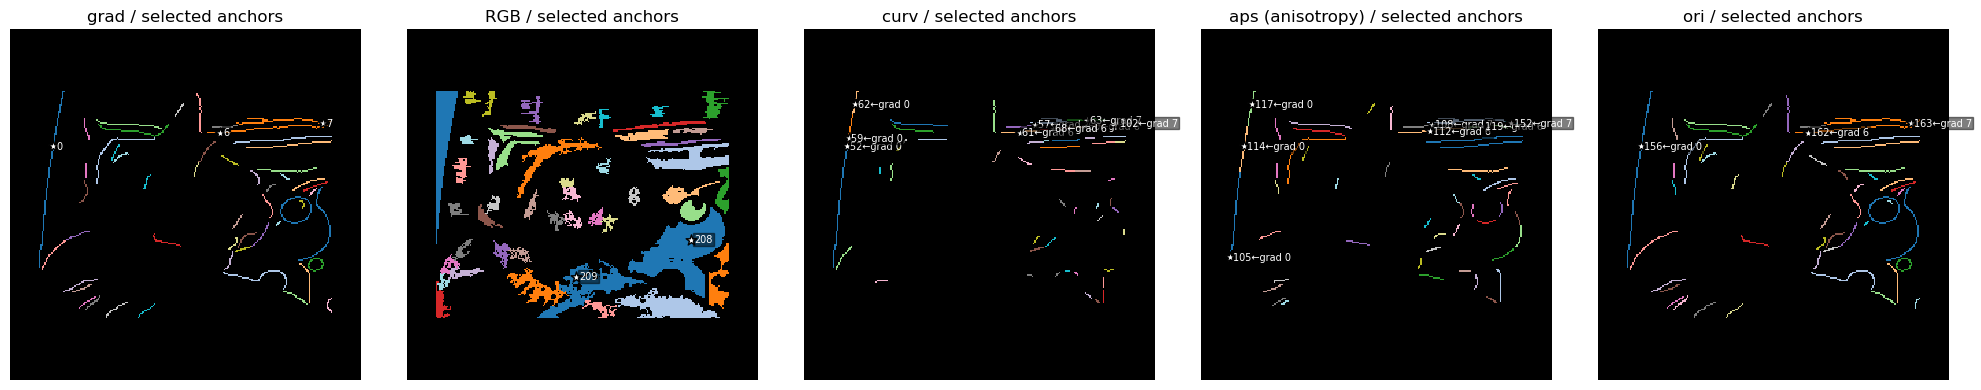

,region,modality,parent_grad,support_parent,completed,pixels,samples,selected,truncated,reason
0,0,grad,None,NaN,True,136,40,True,False,branched_curve_paths
1,1,grad,None,NaN,True,78,48,False,False,selection_budget
2,2,grad,None,NaN,True,67,41,False,False,selection_budget
3,3,grad,None,NaN,True,66,34,False,False,selection_budget
4,4,grad,None,NaN,True,75,26,False,False,selection_budget
...,...,...,...,...,...,...,...,...,...,...
251,251,RGB,None,NaN,True,56,4,False,False,selection_budget
252,252,RGB,None,NaN,True,53,3,False,False,selection_budget
253,253,RGB,None,NaN,True,53,1,False,False,selection_budget
254,254,RGB,None,NaN,True,53,3,False,False,selection_budget


,region,foreground,geometry,sampling,completed
0,0,1.0,1.0,1.0,True
1,6,1.0,1.0,1.0,True
2,7,1.0,1.0,1.0,True
3,52,1.0,1.0,1.0,True
4,57,1.0,1.0,1.0,True
5,59,1.0,1.0,1.0,True
6,60,1.0,1.0,1.0,True
7,61,1.0,1.0,1.0,True
8,62,1.0,1.0,1.0,True
9,63,1.0,1.0,1.0,True


构图: {'build_id': 1, 'shape': (256, 256), 'regions': 256, 'sample_instances': 2641, 'referenced_nodes': 2641, 'region_containers': 256, 'contact_containers': 1024, 'edge_attribute_regions': 0, 'completed_regions': 256, 'truncated_regions': 0, 'edge_observations': 3409, 'rejected': {'nonfinite_pixels': 0, 'advanced_grad_gate_2': 14740, 'advanced_grad_gate_3': 16061, 'advanced_grad_gate_4': 15385, 'local_similarity': 69159, 'direction_conflict': 279, 'junction_connections': 363, 'region_budget': 650, 'small_region': 21603, 'refinement_attribute_discontinuity_2': 749, 'refinement_attribute_discontinuity_3': 449, 'refinement_attribute_discontinuity_4': 15, 'surface_barrier': 33325, 'region_range': 502, 'contact_pair_budget': 12, 'contact_budget': 987}, 'timings': {'supports': 0.0688787120161578, 'regions': 0.2633097419748083, 'contacts': 0.22889900289010257, 'sampling': 0.1578540279297158, 'writing': 0.6972546610049903, 'total': 1.4165396520402282}, 'warnings': []}


,modality,own_gate_pixels,grad_eligible,writable,active,regions,samples,inherited_regions,parent_violations
0,curv,33313,19463,1630,1630,52,307,0,0
1,aps (anisotropy),35524,19463,1630,1630,52,394,0,0
2,ori,34797,19463,1629,1629,52,713,0,0


成员选择: {'selected_leaves': 429, 'rejected': {210: 'selection_budget', 211: 'selection_budget', 5: 'selection_budget', 56: 'parent_selection_budget', 66: 'parent_selection_budget', 92: 'parent_selection_budget', 95: 'parent_selection_budget', 110: 'parent_selection_budget', 111: 'parent_selection_budget', 161: 'parent_selection_budget', 3: 'selection_budget', 83: 'parent_selection_budget', 89: 'parent_selection_budget', 90: 'parent_selection_budget', 99: 'parent_selection_budget', 115: 'parent_selection_budget', 128: 'parent_selection_budget', 133: 'parent_selection_budget', 159: 'parent_selection_budget', 11: 'selection_budget', 64: 'parent_selection_budget', 120: 'parent_selection_budget', 167: 'parent_selection_budget', 13: 'selection_budget', 53: 'parent_selection_budget', 127: 'parent_selection_budget', 129: 'parent_selection_budget', 169: 'parent_selection_budget', 213: 'selection_budget', 215: 'selection_budget', 18: 'selection_budget', 67: 'parent_selection_budget', 174: 'parent_

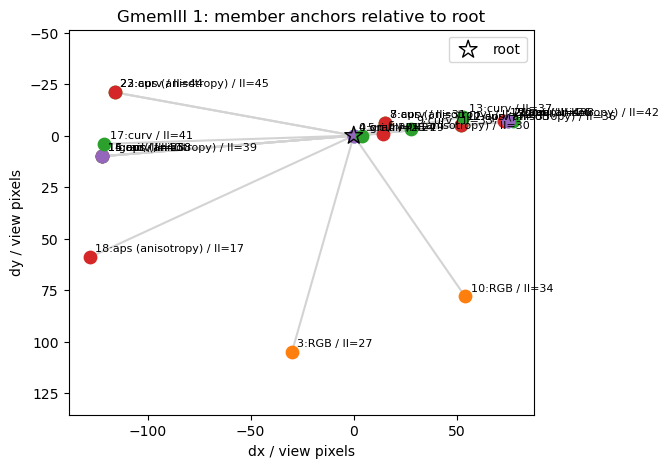

,entity,label,status,members,support,annotation_confirmed,visually_confirmed,reuse_unresolved
0,0,cat,stable,24,1.0,annotation_confirmed,False,False
1,1,cat,stable,24,1.0,annotation_confirmed,False,False


学习后原图自检（非泛化成绩） {'seconds': 1.4568925979547203, 'rejection_reason': None, 'status': 'PREDICTED', 'class_id': 'cat', 'scores': {'cat': 0.6478134393692017, 'dog': 0.0, 'car': 0.0}, 'top_k': [('cat', 0.6478134393692017), ('dog', 0.0), ('car', 0.0)], 'entity_id': 1, 'point': (np.float64(152.7404557969764), np.float64(75.16836560592238)), 'bbox': (12.529170594202498, 75.30542573199357, 399.5291705942025, 375.0), 'search_complete': False, 'assignment_search_complete': False, 'absence_proven': False, 'graph_version': 2}
search audit: {'mode': 'sparse_translation', 'search_complete': False, 'assignment_search_complete': False, 'feature_events': 43714, 'event_budget_dropped': 111139, 'region_pose_pruned_or_dropped': 8163, 'entity_pose_pruned_or_dropped': 1, 'candidate_budget_dropped': 240, 'geometry_evaluations': 129, 'structural_fallback': False}


,entity,score,coverage,evaluable,geometry_error,point
0,1,0.846535,0.982604,1.0,1.414214,"(152.7404557969764, 75.16836560592238)"


普通检索是否找到刚写入实体: True
已知写入原点精验（仅用于定位故障）:


,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons,assignment_diagnostics
0,1,3,"(153.0, 75.0)",0.977547,1.0,0.993296,2.0,True,420,423,0x7fffffffffffdedfffffffffffffffffffffffffffff...,0x7fffffffffffffffffffffffffffffffffffffffffff...,1,[],"{'initial_conflicts': 1, 'conflict_weight': 0...."


,role,template_id,level,point,score,evaluable_coverage,matched_coverage,geometry_error,accepted,matched_roles,evaluated_roles,role_bits_hex,evaluated_bits_hex,version,rejection_reasons,assignment_diagnostics
0,0,24,2,"(153.0, 75.0)",1.000000,1.0,1.000000,1.423858e-14,True,33,33,0x1ffffffff,0x1ffffffff,1,[],{}
1,1,25,2,"(31.0, 85.0)",1.000000,1.0,1.000000,1.432145e-14,True,40,40,0xffffffffff,0xffffffffff,1,[],{}
2,2,26,2,"(228.0, 68.0)",0.999999,1.0,1.000000,1.588711e-14,True,32,32,0xffffffff,0xffffffff,1,[],{}
3,3,27,2,"(123.0, 180.0)",0.999998,1.0,1.000000,7.108896e-15,True,31,31,0x7fffffff,0x7fffffff,1,[],{}
4,4,28,2,"(153.0, 75.0)",0.999999,1.0,1.000000,1.423858e-14,True,21,21,0x1fffff,0x1fffff,1,[],{}
5,5,29,2,"(157.0, 75.0)",1.000000,1.0,1.000000,2.028618e-15,True,8,8,0xff,0xff,1,[],{}
6,6,30,2,"(167.0, 74.0)",1.000000,1.0,1.000000,4.076197e-15,True,11,11,0x7ff,0x7ff,1,[],{}
7,7,31,2,"(168.0, 69.0)",1.000000,1.0,1.000000,3.580362e-15,True,18,18,0x3ffff,0x3ffff,1,[],{}
8,8,32,2,"(168.0, 69.0)",1.000000,1.0,1.000000,7.160723e-15,True,25,25,0x1ffffff,0x1ffffff,1,[],{}
9,9,33,2,"(181.0, 72.0)",1.000000,1.0,1.000000,1.776357e-15,True,6,6,0x3f,0x3f,1,[],{}


,level,template_id,candidates,accepted,best
0,2,42,3,2,"{'point': (92.71245305777954, 80.0), 'score': ..."
1,2,12,3,0,"{'point': (159.6692313106078, 160.0), 'score':..."
2,2,19,3,2,"{'point': (96.0, 116.70670926659447), 'score':..."
3,2,9,3,0,"{'point': (80.42920414539071, 80.8584082907814..."
4,2,8,3,0,"{'point': (228.0, 159.03315123040085), 'score'..."
5,2,15,3,1,"{'point': (64.0, 104.4241548340587), 'score': ..."
6,2,21,3,2,"{'point': (231.01200455049613, 100.0), 'score'..."
7,2,39,3,1,"{'point': (22.0, 150.3763378886249), 'score': ..."
8,2,36,3,0,"{'point': (89.97574255784941, 80.3564319446655..."
9,2,5,3,0,"{'point': (64.0, 102.52790013127934), 'score':..."


重复观察: {'status': 'ALREADY_OBSERVED', 'nodes_unchanged': True, 'support_unchanged': True}


,image_id,class,status,encoder_seconds,learn_seconds,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,000209,cat,ANNOTATED_SEED_CREATED,0.003741,2.64774,732,46,2,3521822720,3242688512,36536832,163577856,239186944


,image_id,class,status,encoder_seconds,learn_seconds,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,007530,cat,ANNOTATED_SEED_CREATED,0.003479,1.479573,321,24,1,3521822720,3242688512,36115968,106954752,239186944
1,000209,cat,ANNOTATED_SEED_CREATED,0.003741,2.647740,732,46,2,3521822720,3242688512,36536832,163577856,239186944


In [21]:
if RUN_SINGLE_DEMOS:
    demo_prediction_2 = run_single_demo(1)
    display(pd.DataFrame(demo_results))
else:
    print('第二张单图演示已关闭。')


## 6. 批量建图：独立记忆、逐目标日志与中断保存

完整数据划分不再随处理上限变化。`BATCH_START_IMAGE` 指定原图游标，处理上限仅控制本次执行范围。`RUN_MEMORY_BUILD=True` 已默认开启，默认处理 20 张原图中全部选定类别目标；`BATCH_IMAGE_LIMIT=None` 扩展到完整建图划分。这里的“批量”是数据集顺序循环，不是并行图写入。单步搜索预算仍默认关闭。

演示记忆会释放，批量模型从空图开始，或从 `RESUME_CHECKPOINT` 恢复。每个目标即时输出状态/原因、节点数量、独立支持、用时及内存；定期和正常结束/手动中断时保存 checkpoint。重跑本节会继续使用当前批量 learner，由 ledger 去重；改变划分或配置应重新初始化。


In [22]:
def serializable(value):
    if isinstance(value,np.generic): return value.item()
    if isinstance(value,np.ndarray): return value.tolist()
    raise TypeError(type(value).__name__)

batch_rows=globals().get('batch_rows',[])
if RUN_MEMORY_BUILD:
    batch_manifest=copy.deepcopy(split_manifest)
    if 'learner' not in globals():
        # 删除演示图及编码器以免并存显存；重新演示需从第 3 节初始化。
        del demo_learner, demo_model, demo_encoder
        gc.collect()
        if DEVICE.type=='cuda': torch.cuda.empty_cache()
        memory_config,encoder,model,learner=new_system()
        if RESUME_CHECKPOINT:
            learner.load(RESUME_CHECKPOINT)
    if RUN_PENDING_MAINTENANCE:
        maintenance=learner.maintain_pending()
        print('pending maintenance:',maintenance)
        save_json(OUTPUT/'pending_maintenance.json',maintenance)
    experiment=SupervisedExperiment(learner,encoder,dataset,batch_manifest)
    OUTPUT.mkdir(parents=True,exist_ok=True)
    (OUTPUT/'split.json').write_text(json.dumps(batch_manifest,ensure_ascii=False,indent=2))
    print('完整建图集:',len(batch_manifest['splits']['memory_build']),
          '本次原图数:',len(experiment.image_window('memory_build',BATCH_IMAGE_LIMIT,BATCH_START_IMAGE)),
          '起点:',BATCH_START_IMAGE,'日志:',OUTPUT,flush=True)
    def record_result(result):
        counts=graph_counts(learner.model)
        row={k:result.get(k) for k in ('image_id','object_id','class_id','status','reason',
            'entity_id','independent_support','encoder_seconds','total_seconds')}
        row['reuse_unresolved']=result.get('reuse_unresolved',False)
        row['geometry_repaired']=result.get('geometry_repaired',False)
        row['initial_write_rejection']=result.get('initial_write_rejection',[])
        row['geometry_retry_prior_stage_seconds']=result.get('geometry_retry_prior_stage_seconds',{})
        row['reuse_decisions']=result.get('reuse_decisions',{})
        row['stage_seconds']=result.get('stage_seconds',{})
        row['work_counts']=result.get('work_counts',{})
        row['modality_counts']=result.get('modality_counts',{})
        row.update(counts)
        row.update(result['resources'])
        batch_rows.append(row)
        with (OUTPUT/'learning.jsonl').open('a') as stream:
            stream.write(json.dumps(row,ensure_ascii=False,default=serializable)+'\n')
        print(row,flush=True)
        if CHECKPOINT_EVERY and len(batch_rows)%CHECKPOINT_EVERY==0:
            learner.save(OUTPUT/'memory.pt')
    try:
        batch_result=experiment.build_memory(search_budget=search_budget,on_result=record_result,
            max_images=BATCH_IMAGE_LIMIT,start_image=BATCH_START_IMAGE,profile_stages=PROFILE_STAGES)
        print(batch_result['status_counts'])
    except KeyboardInterrupt:
        print('已手动中断；保存最后完整提交的图，未完成的目标可重试。')
    finally:
        learner.save(OUTPUT/'memory.pt')
    display(pd.DataFrame(entity_rows(learner.model)))
    print('memory invariants:', audit_memory(learner))
else:
    print('批量训练未启动：完成两图演示后设置 RUN_MEMORY_BUILD=True，再执行本节。')

if 'learner' in globals():
    save_json(OUTPUT/'actual_run_state.json',{'run_id':OUTPUT.name,'graph_version':learner.graph_version,'ledger_size':len(learner.ledger),'resume_from':str(RESUME_CHECKPOINT),'device':str(DEVICE)})


segmentation contract: {'mode': 'grad_refined', 'grad_continuity_threshold': 0.6, 'version': 4}
pending maintenance: {'changed': True, 'graph_version': 35, 'region_states': {'pending': 279, 'resolved_local': 328}, 'unresolved_entities': 31}
完整建图集: 549 本次原图数: 20 起点: 0 日志: /home/p/code/Conscious-linux/Conscious-demo/results/supervised_graph/voc2007_20260923_171046_543975
{'image_id': '003671', 'object_id': '0', 'class_id': 'dog', 'status': 'ALREADY_OBSERVED', 'reason': None, 'entity_id': 0, 'independent_support': None, 'encoder_seconds': 0.003576369024813175, 'total_seconds': 0.003674156963825226, 'reuse_unresolved': False, 'geometry_repaired': False, 'initial_write_rejection': [], 'geometry_retry_prior_stage_seconds': {}, 'reuse_decisions': {}, 'stage_seconds': {'validation': 7.554201874881983e-05}, 'work_counts': {}, 'modality_counts': {}, 'GmemI': 12467, 'GmemII': 758, 'GmemIII': 34, 'peak_rss_bytes': 3521822720, 'rss_bytes': 3277017088, 'cuda_allocated_bytes': 41604096, 'cuda_reserve

,entity,label,status,members,support,annotation_confirmed,visually_confirmed,reuse_unresolved
0,0,dog,stable,24,1.0,annotation_confirmed,False,False
1,1,car,stable,24,1.0,annotation_confirmed,False,False
2,2,car,stable,24,1.0,annotation_confirmed,False,True
3,3,cat,stable,24,1.0,annotation_confirmed,False,True
4,4,dog,stable,24,1.0,annotation_confirmed,False,True
5,5,car,stable,24,1.0,annotation_confirmed,False,True
6,6,dog,stable,24,1.0,annotation_confirmed,False,True
7,7,dog,stable,24,1.0,annotation_confirmed,False,True
8,8,dog,stable,21,1.0,annotation_confirmed,False,True
9,9,dog,stable,24,1.0,annotation_confirmed,False,True


memory invariants: {'broken_roles': 0, 'nonfinite_prototypes': 0, 'bad_ledger': 0, 'modality_patterns': {(0, 2, 3, 4): 2, (0, 1, 2, 3, 4): 32}, 'visually_confirmed': 0}


## 7. 批量运行统计

单个点代表一个标注目标，不是一张原图。RSS 为整个内核进程占用，CUDA reserved 包含缓存；峰值是进程/设备已有统计口径，不等于图本身大小。ALREADY_OBSERVED 不算新增学习成功。


review run: voc2007_20260923_171046_543975 log: /home/p/code/Conscious-linux/Conscious-demo/results/supervised_graph/voc2007_20260923_171046_543975/learning.jsonl


,image_id,object_id,class_id,status,reason,entity_id,independent_support,encoder_seconds,total_seconds,reuse_unresolved,...,work_counts,modality_counts,GmemI,GmemII,GmemIII,peak_rss_bytes,rss_bytes,cuda_allocated_bytes,cuda_reserved_bytes,cuda_peak_allocated_bytes
0,003671,0,dog,ALREADY_OBSERVED,None,0,None,0.003576,0.003674,False,...,{},{},12467,758,34,3521822720,3277017088,41604096,52428800,239186944
1,007490,0,car,ALREADY_OBSERVED,None,1,None,0.003519,0.003620,False,...,{},{},12467,758,34,3521822720,3277017088,40817664,75497472,239186944
2,007490,1,car,ALREADY_OBSERVED,None,2,None,0.003534,0.003614,False,...,{},{},12467,758,34,3521822720,3277017088,41604096,75497472,239186944
3,007530,1,cat,ALREADY_OBSERVED,None,3,None,0.003303,0.003389,False,...,{},{},12467,758,34,3521822720,3277017088,40817664,75497472,239186944
4,007900,0,dog,ALREADY_OBSERVED,None,4,None,0.003312,0.003395,False,...,{},{},12467,758,34,3521822720,3277017088,41604096,75497472,239186944
5,005156,2,car,ALREADY_OBSERVED,None,5,None,0.003343,0.003435,False,...,{},{},12467,758,34,3521822720,3277017088,40817664,75497472,239186944
6,001239,0,dog,ALREADY_OBSERVED,None,6,None,0.003328,0.003420,False,...,{},{},12467,758,34,3521822720,3277017088,41604096,75497472,239186944
7,001239,1,dog,ALREADY_OBSERVED,None,7,None,0.003281,0.003371,False,...,{},{},12467,758,34,3521822720,3277017088,40817664,75497472,239186944
8,001239,2,dog,ALREADY_OBSERVED,None,8,None,0.003179,0.003259,False,...,{},{},12467,758,34,3521822720,3277017088,41604096,75497472,239186944
9,008558,0,dog,ALREADY_OBSERVED,None,9,None,0.003291,0.003381,False,...,{},{},12467,758,34,3521822720,3277017088,40817664,75497472,239186944


,objects
status,
ALREADY_OBSERVED,34


,sum,mean,max
validation,0.002411,0.000071,0.000079


,,objects
status,reason,
ALREADY_OBSERVED,NaN,34


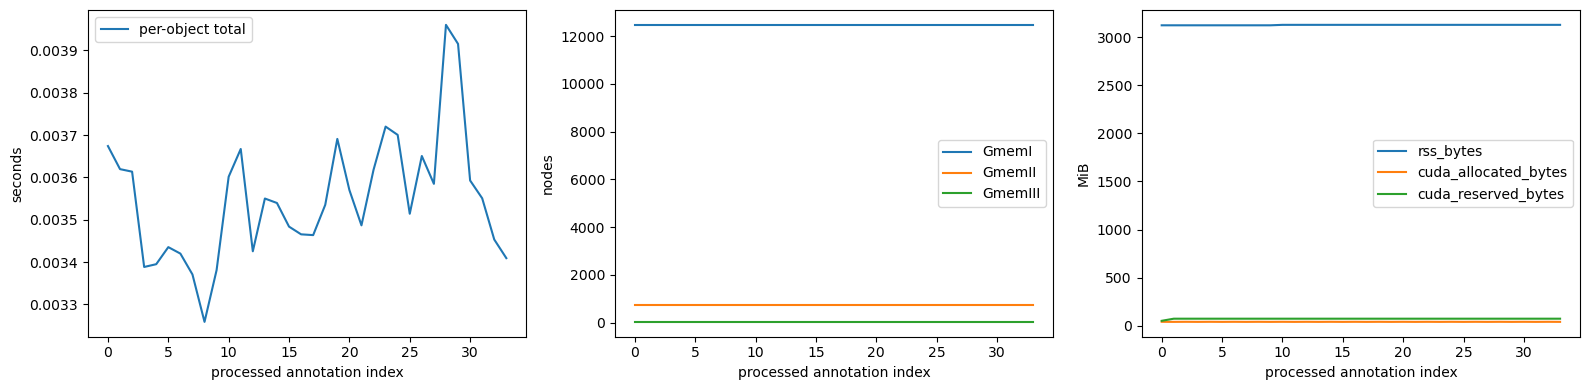

In [23]:
# 汇总明确读取本次目录，避免内核旧 batch_rows 与最新日志混用。
review_log=OUTPUT/'learning.jsonl'
review_rows=[json.loads(line) for line in review_log.read_text().splitlines()] if review_log.exists() else []
print('review run:',OUTPUT.name,'log:',review_log)
if review_rows:
    table=pd.DataFrame(review_rows)
    display(table)
    display(table.groupby('status').size().rename('objects').to_frame())
    display(pd.DataFrame(list(table['stage_seconds'])).fillna(0).agg(['sum','mean','max']).T)
    display(table.groupby(['status','reason'],dropna=False).size().rename('objects').to_frame())
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    axes[0].plot(table['total_seconds'].to_numpy(),label='per-object total')
    axes[0].set_ylabel('seconds'); axes[0].legend()
    for name in ('GmemI','GmemII','GmemIII'):
        axes[1].plot(table[name].to_numpy(),label=name)
    axes[1].set_ylabel('nodes'); axes[1].legend()
    for name in ('rss_bytes','cuda_allocated_bytes','cuda_reserved_bytes'):
        if name in table:
            axes[2].plot(table[name].to_numpy()/2**20,label=name)
    axes[2].set_ylabel('MiB'); axes[2].legend()
    for ax in axes: ax.set_xlabel('processed annotation index')
    plt.tight_layout(); plt.show()
else:
    print('暂无批量记录。')


## 8. 留出查询与可选分类头

所有留出集只查询不写图。小批量中类别缺失时分类头可能拒绝拟合，应扩大样本范围；不要复制训练图片补足留出集。test 未解压时只报告 validation。单图自检结果不参与此处统计。


In [24]:
caches={}; metrics={}; head_results={}
if RUN_QUERY:
    if 'experiment' not in globals() or not learner.ledger:
        raise RuntimeError('先完成建图或检查点恢复。')
    for split in ('readout_fit','validation','test'):
        if not experiment.splits['splits'][split]:
            print(split,'为空，跳过'); continue
        caches[split]=experiment.query_split(split,exact=False,max_images=QUERY_IMAGE_LIMIT,output_dir=OUTPUT,
            on_result=lambda row:print('query',row['image_id'],row['object_id'],row['prediction']['rejection_reason'],flush=True))
        if split!='readout_fit':
            metrics[split]=experiment.evaluate(caches[split]);print(split,metrics[split])
        print(split,'accepted unique rows:',len(torch.unique(caches[split]['features'],dim=0)),
              'weak unique rows:',len(torch.unique(caches[split]['weak_features'],dim=0)))
    save_json(OUTPUT/'readout_metrics.json',metrics)
trainer=None
if RUN_HEAD_FIT:
    for source in ('accepted','weak') if RUN_WEAK_HEAD else ('accepted',):
        local={name:{**cache,'features':cache['features' if source=='accepted' else 'weak_features'],'feature_source':source}
               for name,cache in caches.items()}
        if not all(name in local for name in ('readout_fit','validation')):
            head_results[source]={'status':'SKIPPED','reason':'missing independent fit/validation split'};continue
        fit=local['readout_fit'];val=local['validation']
        if set(fit['targets'].tolist()) != set(range(len(classes))):
            head_results[source]={'status':'SKIPPED','reason':'fit window lacks a class; expand the window'};continue
        if len(torch.unique(fit['features'],dim=0))<2:
            head_results[source]={'status':'SKIPPED','reason':'constant evidence vectors; head cannot recover missing information'};continue
        if not len(val['targets']):
            head_results[source]={'status':'SKIPPED','reason':'empty validation'};continue
        seed_results={}
        for seed in HEAD_SEEDS:
            head_config=copy.deepcopy(config);head_config.seed=seed
            trainer=ClassifierTrainer(classes,learner.graph_version,head_config,device=DEVICE)
            history=trainer.fit(fit,val,experiment.splits['splits']['memory_build'])
            seed_results[str(seed)]={'history':history,'best_epoch':trainer.best_epoch,
                'evaluation_policy':'closed-set argmax; not calibrated entity acceptance',
                'metrics':{name:experiment.evaluate(cache,trainer) for name,cache in local.items() if name!='readout_fit'}}
            learner.save(OUTPUT/f'memory_and_{source}_head_seed{seed}.pt',trainer)
            print(source,'seed',seed,'best_epoch',trainer.best_epoch,seed_results[str(seed)]['metrics'])
            display(pd.DataFrame(history))
        head_results[source]={'status':'FIT','feature_source':source,'seeds':seed_results,
            'selection_policy':'each seed uses validation loss including epoch -1; no test selection'}
    save_json(OUTPUT/'head_results.json',head_results)

# Fixed baselines expose class collapse; no test-based rule selection.
from nns.memorygraphs.supervised_readout import classification_metrics
baselines={}
fit_targets=caches.get('readout_fit',{}).get('targets',torch.empty(0,dtype=torch.long))
majority=int(torch.bincount(fit_targets,minlength=len(classes)).argmax()) if len(fit_targets) else None
for split,cache in caches.items():
    if split=='readout_fit' or not len(cache['targets']):continue
    scores=cache['weak_features'].reshape(-1,len(classes),6)
    rules={'weak_score':scores[:,:,0].argmax(1),'weak_score_coverage':(scores[:,:,0]*scores[:,:,2]).argmax(1)}
    if majority is not None:rules['fit_majority']=torch.full_like(cache['targets'],majority)
    rules.update({f'constant_{label}':torch.full_like(cache['targets'],i) for i,label in enumerate(classes)})
    truth=[classes[int(i)] for i in cache['targets']]
    baselines[split]={name:classification_metrics(truth,[{'class_id':classes[int(i)],'status':'PREDICTED'} for i in pred],classes) for name,pred in rules.items()}
save_json(OUTPUT/'classification_baselines.json',baselines)
print('fixed baselines:',baselines)


query 002215 0 no_accepted_entity
query 002215 1 no_accepted_entity
query 002215 2 no_accepted_entity
query 002215 3 no_accepted_entity
query 002215 4 no_accepted_entity
query 002196 0 no_accepted_entity
query 000805 0 no_accepted_entity
query 009029 0 no_accepted_entity
query 002315 0 no_accepted_entity
query 006654 1 no_accepted_entity
query 005047 0 no_accepted_entity
query 007968 0 no_accepted_entity
query 002730 0 no_accepted_entity
query 008322 0 no_accepted_entity
query 008322 1 no_accepted_entity
query 007974 0 no_accepted_entity
query 000474 0 no_accepted_entity
query 006597 0 no_accepted_entity
query 007166 0 no_accepted_entity
query 007166 1 no_accepted_entity
query 008037 0 no_accepted_entity
query 002466 0 no_accepted_entity
query 006189 1 no_accepted_entity
query 004929 0 no_accepted_entity
query 009098 0 no_accepted_entity
query 009098 1 no_accepted_entity
query 000965 0 no_accepted_entity
readout_fit accepted unique rows: 1 weak unique rows: 27
query 000007 0 no_accepte

,epoch,updates,training_loss,validation_loss,training_accuracy,training_macro_f1,training_recall,training_predicted_counts,validation_accuracy,validation_macro_f1,validation_recall,validation_predicted_counts
0,-1,0,1.249565,1.060614,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.461538,0.397647,"[0.5, 0.1666666716337204, 0.5714285969734192]","[11, 4, 11]"
1,0,1,1.246532,1.060021,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.461538,0.397647,"[0.5, 0.1666666716337204, 0.5714285969734192]","[11, 4, 11]"
2,1,2,1.243526,1.059443,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
3,2,3,1.240547,1.058887,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
4,3,4,1.237596,1.058361,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
5,4,5,1.234672,1.057875,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
6,5,6,1.231775,1.057436,0.259259,0.260626,"[0.3333333432674408, 0.1666666716337204, 0.333...","[14, 5, 8]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
7,6,7,1.228905,1.057048,0.259259,0.257003,"[0.3333333432674408, 0.1666666716337204, 0.333...","[12, 5, 10]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
8,7,8,1.226061,1.056711,0.259259,0.257003,"[0.3333333432674408, 0.1666666716337204, 0.333...","[12, 5, 10]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"
9,8,9,1.223244,1.056428,0.259259,0.257003,"[0.3333333432674408, 0.1666666716337204, 0.333...","[12, 5, 10]",0.500000,0.437037,"[0.6666666865348816, 0.1666666716337204, 0.571...","[12, 4, 10]"


weak seed 1 best_epoch 49 {'validation': {'accuracy': 0.34615384615384615, 'macro_f1': 0.342914979757085, 'recall': {'cat': 0.6666666666666666, 'dog': 0.3333333333333333, 'car': 0.21428571428571427}, 'confusion': [[4, 1, 1, 0], [2, 2, 2, 0], [7, 4, 3, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 1.0, 'accepted_accuracy': 0.34615384615384615, 'unresolved_rate': 0.0, 'samples': 26}, 'test': {'accuracy': 0.2903225806451613, 'macro_f1': 0.29686274509803917, 'recall': {'cat': 0.6666666666666666, 'dog': 0.4444444444444444, 'car': 0.0625}, 'confusion': [[4, 1, 1, 0], [3, 4, 2, 0], [12, 3, 1, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 1.0, 'accepted_accuracy': 0.2903225806451613, 'unresolved_rate': 0.0, 'samples': 31}}


,epoch,updates,training_loss,validation_loss,training_accuracy,training_macro_f1,training_recall,training_predicted_counts,validation_accuracy,validation_macro_f1,validation_recall,validation_predicted_counts
0,-1,0,1.149757,1.335831,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.293086,"[0.8333333134651184, 0.5, 0.0]","[13, 11, 2]"
1,0,1,1.147154,1.334885,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.293086,"[0.8333333134651184, 0.5, 0.0]","[13, 11, 2]"
2,1,2,1.144574,1.333959,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.293086,"[0.8333333134651184, 0.5, 0.0]","[13, 11, 2]"
3,2,3,1.142018,1.333052,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.293086,"[0.8333333134651184, 0.5, 0.0]","[13, 11, 2]"
4,3,4,1.139487,1.332163,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.293086,"[0.8333333134651184, 0.5, 0.0]","[13, 11, 2]"
5,4,5,1.136979,1.331289,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.291667,"[0.8333333134651184, 0.5, 0.0]","[14, 10, 2]"
6,5,6,1.134497,1.330429,0.296296,0.296296,"[0.2222222238779068, 0.3333333432674408, 0.333...","[9, 12, 6]",0.307692,0.291667,"[0.8333333134651184, 0.5, 0.0]","[14, 10, 2]"
7,6,7,1.132038,1.329580,0.333333,0.322876,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 13, 6]",0.307692,0.300439,"[0.8333333134651184, 0.5, 0.0]","[13, 10, 3]"
8,7,8,1.129604,1.328739,0.333333,0.322876,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 13, 6]",0.307692,0.300439,"[0.8333333134651184, 0.5, 0.0]","[13, 10, 3]"
9,8,9,1.127193,1.327906,0.333333,0.322876,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 13, 6]",0.307692,0.300439,"[0.8333333134651184, 0.5, 0.0]","[13, 10, 3]"


weak seed 2 best_epoch 40 {'validation': {'accuracy': 0.38461538461538464, 'macro_f1': 0.3331868131868132, 'recall': {'cat': 0.3333333333333333, 'dog': 0.16666666666666666, 'car': 0.5}, 'confusion': [[2, 3, 1, 0], [2, 1, 3, 0], [4, 3, 7, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 1.0, 'accepted_accuracy': 0.38461538461538464, 'unresolved_rate': 0.0, 'samples': 26}, 'test': {'accuracy': 0.3870967741935484, 'macro_f1': 0.36388888888888893, 'recall': {'cat': 0.5, 'dog': 0.2222222222222222, 'car': 0.4375}, 'confusion': [[3, 1, 2, 0], [2, 2, 5, 0], [5, 4, 7, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 1.0, 'accepted_accuracy': 0.3870967741935484, 'unresolved_rate': 0.0, 'samples': 31}}


,epoch,updates,training_loss,validation_loss,training_accuracy,training_macro_f1,training_recall,training_predicted_counts,validation_accuracy,validation_macro_f1,validation_recall,validation_predicted_counts
0,-1,0,1.127569,1.215631,0.370370,0.358603,"[0.3333333432674408, 0.4166666567325592, 0.333...","[9, 11, 7]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
1,0,1,1.124616,1.214551,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
2,1,2,1.121693,1.213490,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
3,2,3,1.118800,1.212449,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
4,3,4,1.115937,1.211428,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
5,4,5,1.113105,1.210428,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
6,5,6,1.110305,1.209449,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.358974,"[0.3333333432674408, 0.1666666716337204, 0.571...","[7, 7, 12]"
7,6,7,1.107535,1.208490,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.359924,"[0.3333333432674408, 0.1666666716337204, 0.571...","[6, 7, 13]"
8,7,8,1.104798,1.207553,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.359924,"[0.3333333432674408, 0.1666666716337204, 0.571...","[6, 7, 13]"
9,8,9,1.102092,1.206638,0.333333,0.318597,"[0.2222222238779068, 0.4166666567325592, 0.333...","[8, 11, 8]",0.423077,0.359924,"[0.3333333432674408, 0.1666666716337204, 0.571...","[6, 7, 13]"


fixed baselines: {'validation': {'weak_score': {'accuracy': 0.5, 'macro_f1': 0.37142857142857144, 'recall': {'cat': 0.0, 'dog': 0.5, 'car': 0.7142857142857143}, 'confusion': [[0, 5, 1, 0], [0, 3, 3, 0], [3, 1, 10, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 1.0, 'accepted_accuracy': 0.5, 'unresolved_rate': 0.0, 'samples': 26}, 'weak_score_coverage': {'accuracy': 0.5384615384615384, 'macro_f1': 0.3862068965517242, 'recall': {'cat': 0.0, 'dog': 0.5, 'car': 0.7857142857142857}, 'confusion': [[0, 5, 1, 0], [0, 3, 3, 0], [2, 1, 11, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 1.0, 'accepted_accuracy': 0.5384615384615384, 'unresolved_rate': 0.0, 'samples': 26}, 'fit_majority': {'accuracy': 0.23076923076923078, 'macro_f1': 0.125, 'recall': {'cat': 0.0, 'dog': 1.0, 'car': 0.0}, 'confusion': [[0, 6, 0, 0], [0, 6, 0, 0], [0, 14, 0, 0]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'co

## 9. 可选无框检测

当前默认 RUN_DETECTION=False，优先验证已知框识别；需要时可手动开启。只给整图生成候选和预测，真值仅用于事后评价。优先使用官方 test，未解压时明确使用 validation。此处单图和过滤 difficult 后的简化 AP 均不能称为 VOC 官方测试 mAP。


In [25]:
if RUN_DETECTION:
    if 'learner' not in globals() or not learner.ledger:
        raise RuntimeError('请先完成批量监督建图。')
    split='test' if experiment.splits['splits']['test'] else 'validation'
    image_id=experiment.splits['splits'][split][0]
    image,objects=dataset.load_image_objects(image_id)
    prediction=ProposalDetector(learner,encoder).detect(image,image_id=image_id)
    print('evaluation split:',split)
    print({k:v for k,v in prediction.items() if k not in ('proposals','detections','proposal_audits')})
    display(pd.DataFrame(prediction['detections']))
    detection_result=detection_metrics(prediction['detections'],{image_id:objects},classes,
        iou_threshold=.5,proposals={image_id:prediction['proposals']})
    print(detection_result)
    save_json(OUTPUT/'detection.json',{'image_id':image_id,'prediction':prediction,'metrics':detection_result})

else:
    print('无框检测已关闭：先验证已知框结构检索，避免重复执行 211 个滑窗候选。')


无框检测已关闭：先验证已知框结构检索，避免重复执行 211 个滑窗候选。


## 10. 冻结记忆回查（训练回忆率，不是泛化成绩）
RUN_TRAINING_RECALL 已默认开启，在建图/恢复之后执行。目标实体命中、仅同类命中、异类命中与未命中分别统计；NOT_COMMITTED 不计入已提交对象的召回率。

In [26]:
if RUN_TRAINING_RECALL:
    if 'experiment' not in globals():
        raise RuntimeError('先建立或加载本实验的记忆与 experiment。')
    recall_result=experiment.audit_memory_recall(max_images=BATCH_IMAGE_LIMIT,start_image=BATCH_START_IMAGE,
        on_result=lambda row:print('recall',row['image_id'],row['object_id'],row['status'],flush=True))
    print('run:',OUTPUT.name,'graph_version:',recall_result['graph_version'])
    print(recall_result['status_counts'])
    print('training classification correct:',sum(row.get('classification_correct',False) for row in recall_result['rows']))
    display(pd.DataFrame(recall_result['rows']))
    OUTPUT.mkdir(parents=True,exist_ok=True)
    save_json(OUTPUT/'training_recall.json',recall_result)
else:
    print('训练集回查未启动；它与留出集 RUN_QUERY 分开执行。')


recall 003671 0 TARGET_HIT
recall 007490 0 TARGET_HIT
recall 007490 1 TARGET_HIT
recall 007530 1 TARGET_HIT
recall 007900 0 TARGET_HIT
recall 005156 2 TARGET_HIT
recall 001239 0 TARGET_HIT
recall 001239 1 TARGET_HIT
recall 001239 2 TARGET_HIT
recall 008558 0 TARGET_HIT
recall 008558 1 TARGET_HIT
recall 008558 2 TARGET_HIT
recall 004228 0 TARGET_HIT
recall 004228 2 TARGET_HIT
recall 005071 0 TARGET_HIT
recall 005071 7 TARGET_HIT
recall 005071 8 TARGET_HIT
recall 005071 9 TARGET_HIT
recall 005071 11 TARGET_HIT
recall 005071 12 TARGET_HIT
recall 005071 14 TARGET_HIT
recall 002056 1 TARGET_HIT
recall 000036 0 TARGET_HIT
recall 008980 0 TARGET_HIT
recall 008968 0 TARGET_HIT
recall 000209 0 TARGET_HIT
recall 001404 0 TARGET_HIT
recall 006459 6 TARGET_HIT
recall 007905 0 TARGET_HIT
recall 005273 0 TARGET_HIT
recall 005273 1 TARGET_HIT
recall 003261 0 TARGET_HIT
recall 008169 0 TARGET_HIT
recall 008169 1 TARGET_HIT
run: voc2007_20260923_171046_543975 graph_version: 35
{'TARGET_HIT': 34}
traini

,image_id,object_id,class_id,target_entity_id,hits,prediction,classification_correct,status,structural_fallback,graph_version
0,003671,0,dog,0,[0],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
1,007490,0,car,1,[1],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
2,007490,1,car,2,[2],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
3,007530,1,cat,3,[3],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
4,007900,0,dog,4,[4],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
5,005156,2,car,5,[5],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
6,001239,0,dog,6,[6],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
7,001239,1,dog,7,[7],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
8,001239,2,dog,8,[8],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35
9,008558,0,dog,9,[9],"{'rejection_reason': None, 'status': 'PREDICTE...",True,TARGET_HIT,True,35


## 11. 冻结熟悉度／差异探针

最多三个训练对象（优先不同类别）的小扰动和布局反例；只读、不增加学习证据。图示顺序为输入、熟悉、可靠差异、未知。布局打乱是结构对照，不保证成为另一语义类别。


pilot 003671 identity True reinforce_known
pilot 003671 translation True reinforce_known
pilot 003671 scale False insufficient_correspondence
pilot 003671 brightness True reinforce_known
pilot 003671 occlusion False hold_correspondence
pilot 003671 layout_negative False insufficient_correspondence
pilot 007490 identity True reinforce_known
pilot 007490 translation True reinforce_known
pilot 007490 scale False insufficient_correspondence
pilot 007490 brightness True reinforce_known
pilot 007490 occlusion False hold_correspondence
pilot 007490 layout_negative False insufficient_correspondence
pilot 007530 identity True reinforce_known
pilot 007530 translation True reinforce_known
pilot 007530 scale False insufficient_correspondence
pilot 007530 brightness True reinforce_known
pilot 007530 occlusion False insufficient_correspondence
pilot 007530 layout_negative False insufficient_correspondence


,image_id,variant,target_hit,candidate_id,anchor_families,familiar,difference,unknown,action,difference_changed,difference_unchanged
0,003671,identity,True,0,3,0.999996,0.000004,7.401487e-17,reinforce_known,NaN,0.000003
1,003671,translation,True,0,3,0.999885,0.000115,7.401487e-17,reinforce_known,NaN,0.000114
2,003671,scale,False,0,1,0.611181,0.388819,7.401487e-17,insufficient_correspondence,NaN,0.398685
3,003671,brightness,True,0,3,0.999986,0.000014,7.401487e-17,reinforce_known,0.000014,NaN
4,003671,occlusion,False,0,3,0.930825,0.069175,7.401487e-17,hold_correspondence,0.207518,0.060502
5,003671,layout_negative,False,0,2,0.333069,0.166931,5.000000e-01,insufficient_correspondence,0.500000,0.000381
6,007490,identity,True,1,6,0.999963,0.000037,9.251859e-17,reinforce_known,NaN,0.000057
7,007490,translation,True,1,6,0.940035,0.059965,9.251859e-17,reinforce_known,NaN,0.061856
8,007490,scale,False,28,0,0.206500,0.516692,2.768078e-01,insufficient_correspondence,NaN,0.526678
9,007490,brightness,True,1,6,0.965132,0.034868,9.251859e-17,reinforce_known,0.033069,NaN


pilot verdict: fix_scale_and_partial_correspondence_before_learning
limits: ['Frozen diagnostic, not an implemented learning algorithm.', 'Layout scrambling is a structural control, not a guaranteed different semantic class.', 'Three maps cover predicted template support only; unexplained foreground needs segmentation association.', 'Occlusion mask is evaluation-only; flat occluders may remain confidently different, not unknown.']


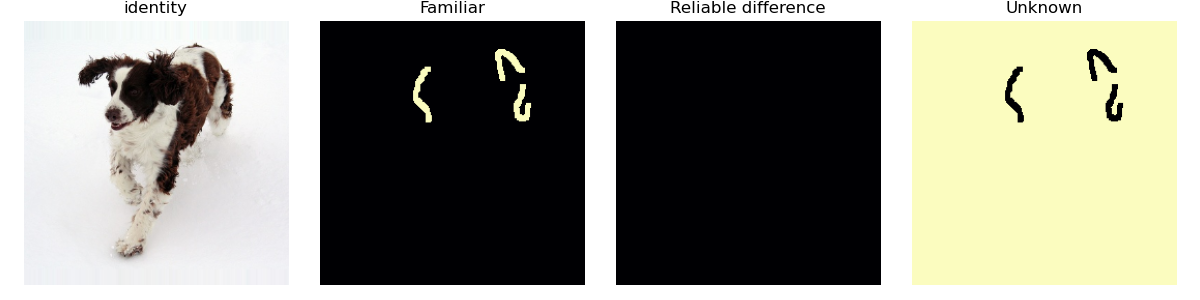

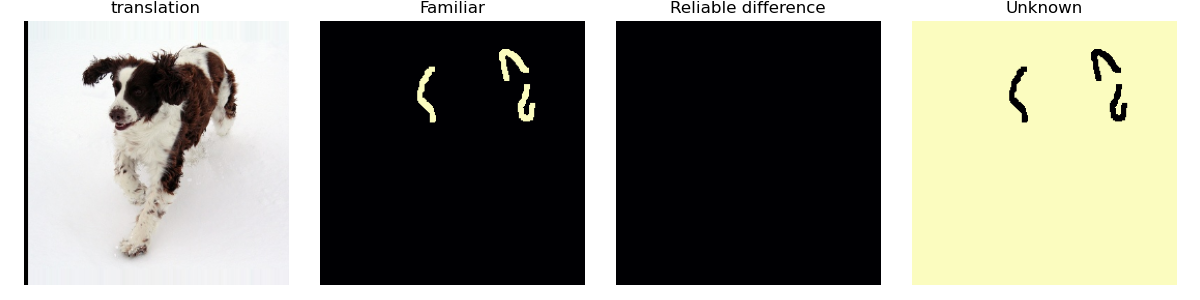

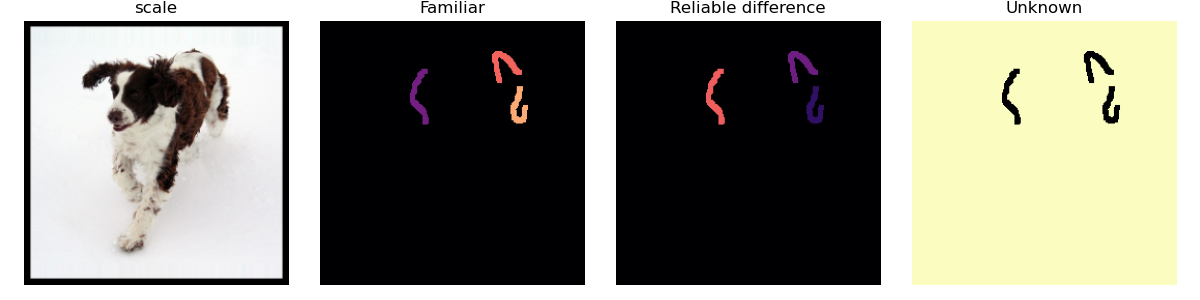

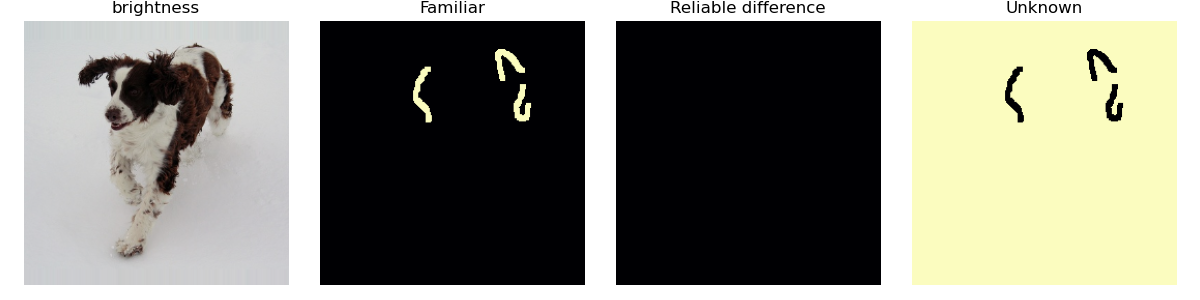

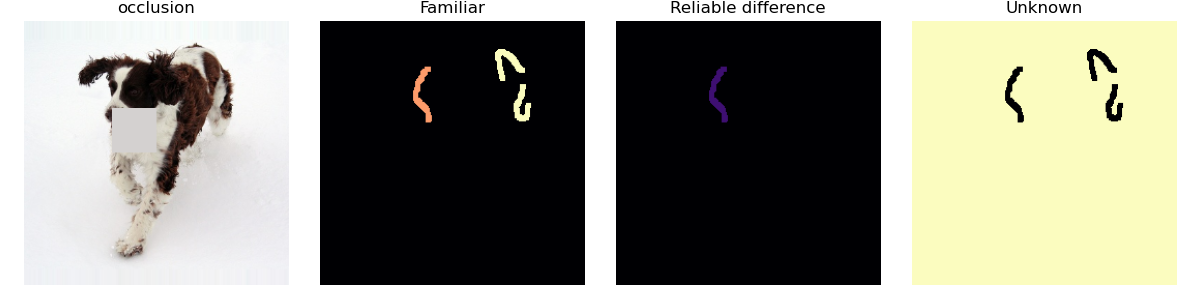

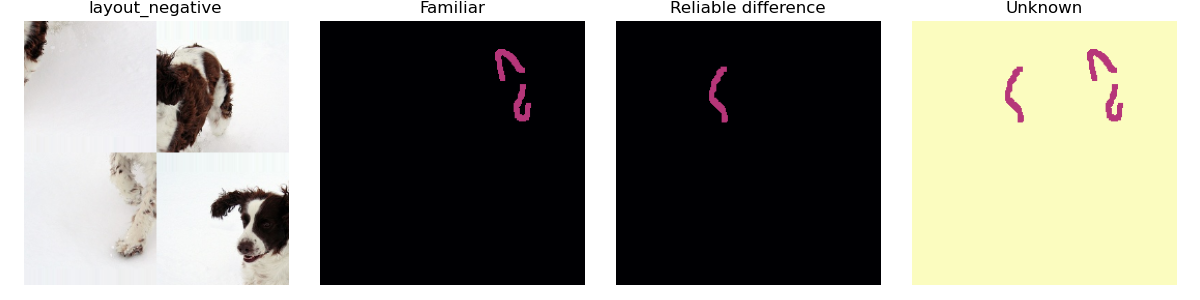

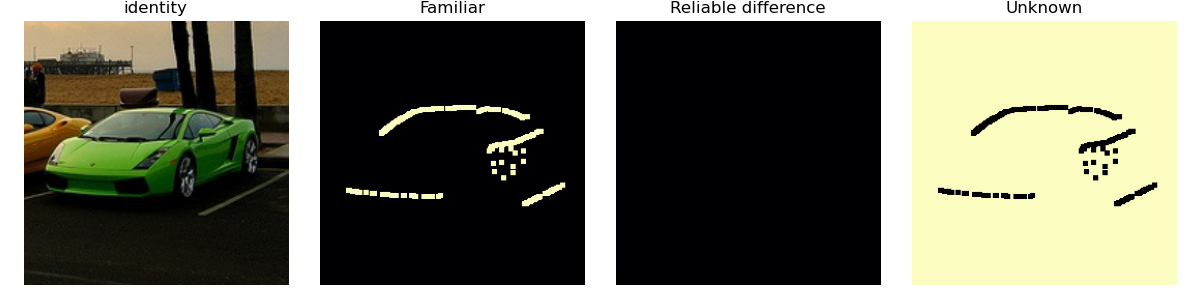

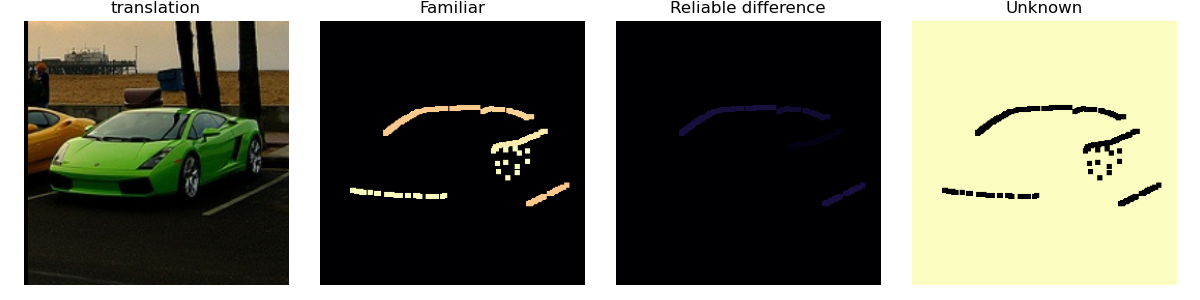

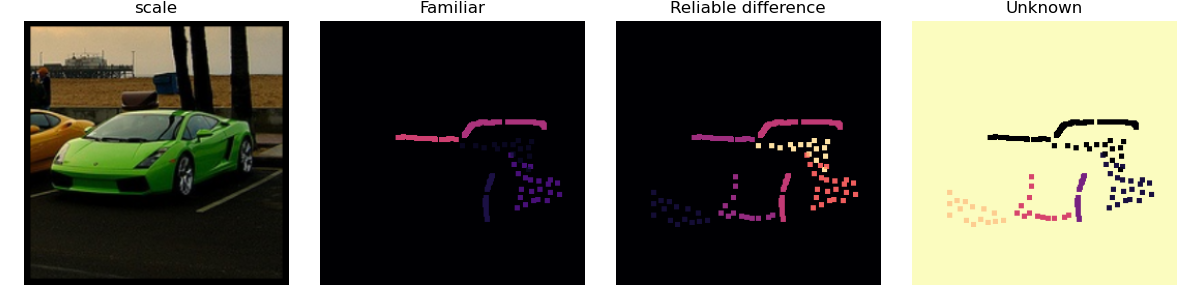

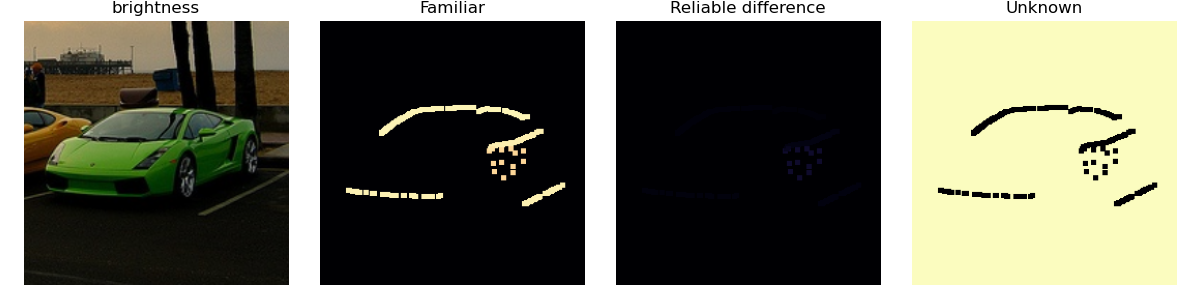

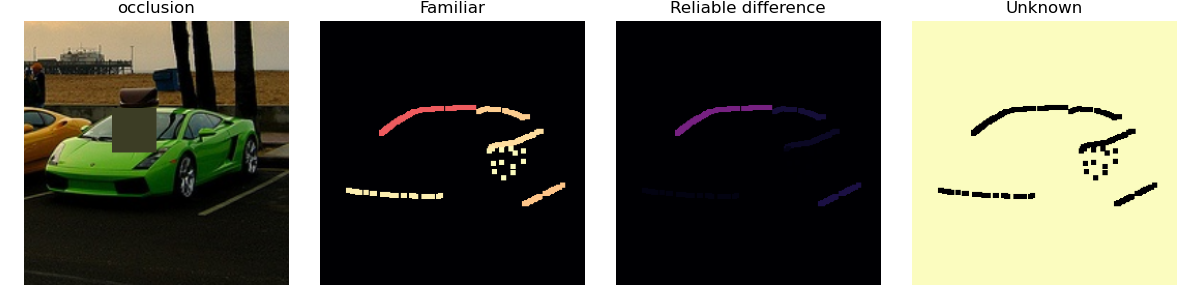

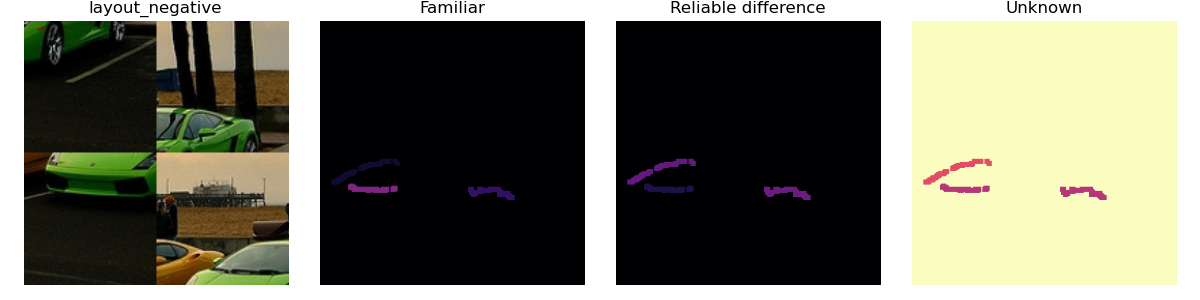

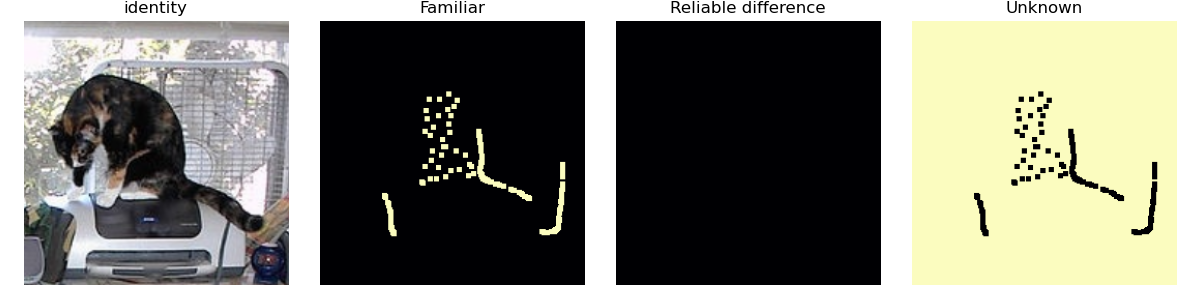

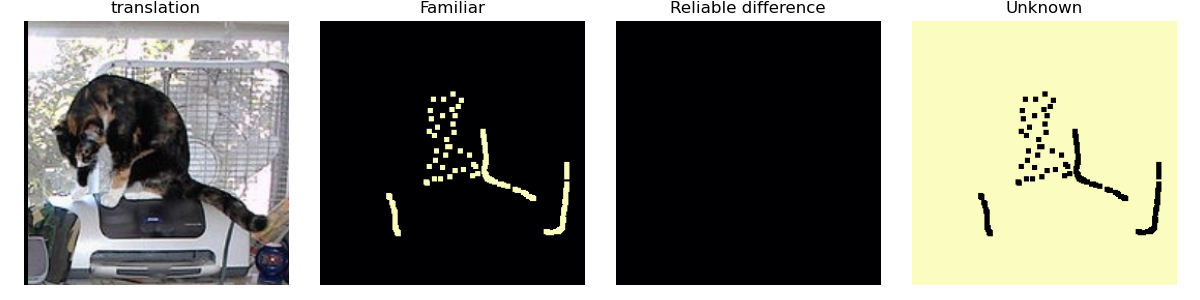

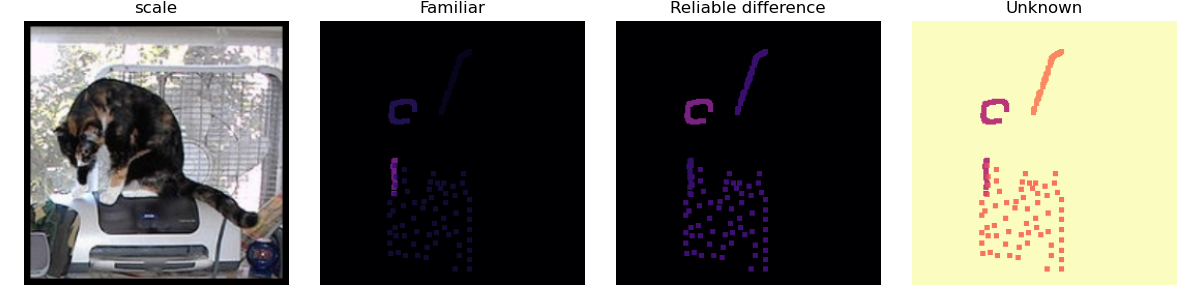

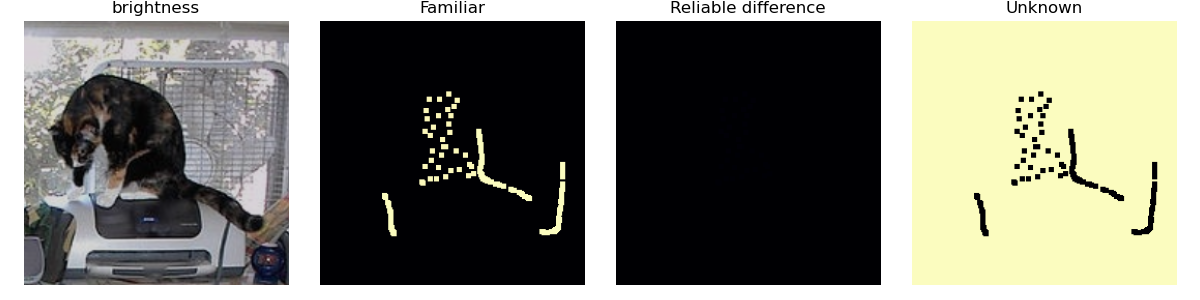

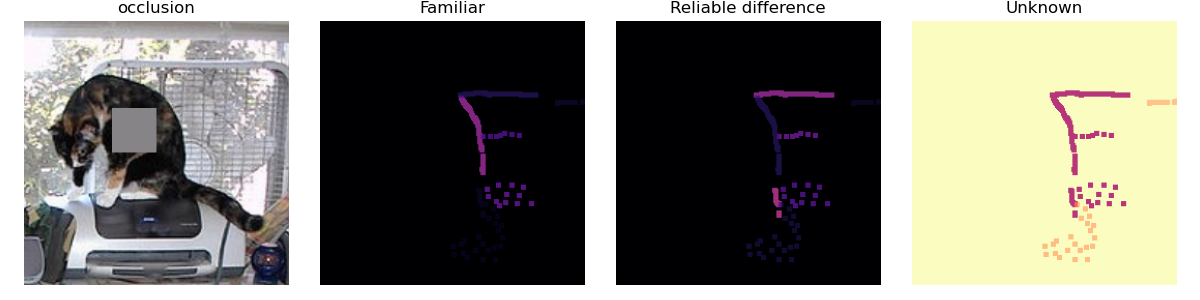

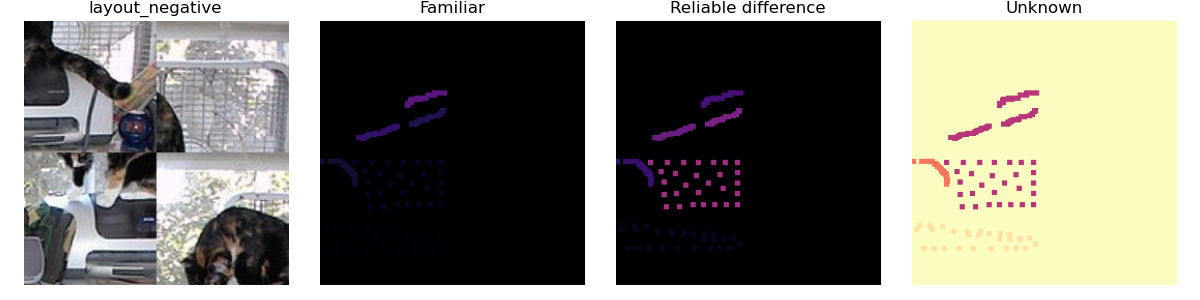

已知变换列仅为离线诊断，不计入普通检索成绩。


,image_id,variant,identity_verified,rejection,conflicts_before,repair,changed_comparable_fraction,oracle_original_geometry,oracle_scaled_geometry
0,003671,identity,True,[],0,NaN,NaN,True,True
1,003671,translation,True,[],0,NaN,NaN,True,True
2,003671,scale,False,"[score, matched_coverage, evidence_conflict]",83,no_bounded_solution,NaN,False,False
3,003671,brightness,True,[],0,NaN,0.016296,True,True
4,003671,occlusion,False,[score],3,reassigned,0.047052,False,False
5,003671,layout_negative,False,"[score, matched_coverage]",0,NaN,0.011383,None,None
6,007490,identity,True,[],0,NaN,NaN,True,True
7,007490,translation,True,[],1,reassigned,NaN,True,True
8,007490,scale,False,"[score, matched_coverage, evidence_conflict]",24,no_bounded_solution,NaN,False,False
9,007490,brightness,True,[],33,reassigned,0.032928,True,True


In [27]:
if RUN_FAMILIARITY_PILOT:
    pilot=run_familiarity_pilot(experiment,OUTPUT/'familiarity_pilot',ProbeConfig(max_objects=PILOT_OBJECT_LIMIT),
        on_result=lambda row:print('pilot',row['image_id'],row['variant'],row['target_hit'],row['action'],flush=True))
    display(pd.DataFrame([{k:r.get(k) for k in ('image_id','variant','target_hit','candidate_id','anchor_families','familiar','difference','unknown','action','difference_changed','difference_unchanged')} for r in pilot['rows']]))
    print('pilot verdict:',pilot['verdict']);print('limits:',pilot['limitations'])
    from IPython.display import Image as DisplayImage
    for row in pilot['rows']:
        path=OUTPUT/'familiarity_pilot'/f"{row['image_id']}_{row['object_id']}_{row['variant']}.png"
        display(DisplayImage(filename=str(path)))

    diagnostic_rows=[]
    for r in pilot['rows']:
        oracle=r.get('known_transform_diagnostic',{})
        diagnostic_rows.append({'image_id':r['image_id'],'variant':r['variant'],
            'identity_verified':r.get('identity_verified'),'rejection':r.get('rejection_reasons'),
            'conflicts_before':r.get('assignment_diagnostics',{}).get('initial_conflicts',0),
            'repair':r.get('assignment_diagnostics',{}).get('status'),
            'changed_comparable_fraction':r.get('changed_comparable_fraction'),
            'oracle_original_geometry':oracle.get('known_center_original_geometry',{}).get('accepted'),
            'oracle_scaled_geometry':oracle.get('known_center_transformed_geometry',{}).get('accepted')})
    print('已知变换列仅为离线诊断，不计入普通检索成绩。')
    display(pd.DataFrame(diagnostic_rows))


## 12. 检查点恢复与统一结果

恢复验证使用新对象加载保存快照，不覆盖当前图。查询、回查、探针均不能写学习证据；仅在训练前显式整理待决元数据。


In [28]:
if RUN_RESUME_CHECK:
    learner.save(OUTPUT/'memory.pt')
    restored=SupervisedGraphOptimizer(MultilevelCoordinator(memory_config),classes,config)
    restored.load(OUTPUT/'memory.pt')
    resume_check={'graph_version_equal':restored.graph_version==learner.graph_version,
        'ledger_equal':restored.ledger==learner.ledger,'counts_equal':graph_counts(restored.model)==graph_counts(learner.model)}
    _,check_observation=next(experiment._objects('memory_build',experiment.image_window('memory_build',1)))
    check_features=encoder(check_observation)
    before=restored.graph_version
    replay=restored.learn_object(check_observation,check_features)
    resume_check['replay_idempotent']=replay['status']=='ALREADY_OBSERVED' and restored.graph_version==before
    left=learner.model.query_hierarchy(check_features,valid_mask=check_observation.valid_mask)
    right=restored.model.query_hierarchy(check_features,valid_mask=check_observation.valid_mask)
    left_matches=sorted(left.entities,key=lambda m:(m.template_id,*m.point))
    right_matches=sorted(right.entities,key=lambda m:(m.template_id,*m.point))
    resume_check['query_equivalent']=len(left_matches)==len(right_matches) and all(
        a.template_id==b.template_id and np.allclose((*a.point,a.score),(*b.point,b.score),rtol=1e-6,atol=1e-6)
        for a,b in zip(left_matches,right_matches))
    save_json(OUTPUT/'resume_check.json',resume_check);print(resume_check)
    assert all(resume_check.values()),'恢复或重放一致性失败，停止扩容'
    del restored
summary={'run_id':OUTPUT.name,'graph_version':learner.graph_version,'memory':graph_counts(learner.model)}
for name in ('readout_metrics','head_results','classification_baselines','training_recall','detection','resume_check','pending_maintenance'):
    path=OUTPUT/(name+'.json')
    if path.exists():
        value=json.loads(path.read_text())
        summary[name]=value.get('status_counts',value.get('metrics',value))
path=OUTPUT/'familiarity_pilot/summary.json'
if path.exists():
    value=json.loads(path.read_text());summary['familiarity_pilot']={'verdict':value['verdict'],'cohort_objects':value['cohort_objects'],'limitations':value['limitations']}
save_json(OUTPUT/'all_results.json',summary)
print('全部结果目录:',OUTPUT)
print('readout:',summary.get('readout_metrics'))
print('recall:',summary.get('training_recall'))
print('new algorithm:',summary.get('familiarity_pilot'))


{'graph_version_equal': True, 'ledger_equal': True, 'counts_equal': True, 'replay_idempotent': True, 'query_equivalent': True}
全部结果目录: /home/p/code/Conscious-linux/Conscious-demo/results/supervised_graph/voc2007_20260923_171046_543975
readout: {'validation': {'accuracy': 0.0, 'macro_f1': 0.0, 'recall': {'cat': 0.0, 'dog': 0.0, 'car': 0.0}, 'confusion': [[0, 0, 0, 6], [0, 0, 0, 6], [0, 0, 0, 14]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 0.0, 'accepted_accuracy': None, 'unresolved_rate': 1.0, 'samples': 26}, 'test': {'accuracy': 0.0, 'macro_f1': 0.0, 'recall': {'cat': 0.0, 'dog': 0.0, 'car': 0.0}, 'confusion': [[0, 0, 0, 6], [0, 0, 0, 9], [0, 0, 0, 16]], 'prediction_columns': ['cat', 'dog', 'car', 'REJECTED_OR_UNRESOLVED'], 'coverage': 0.0, 'accepted_accuracy': None, 'unresolved_rate': 1.0, 'samples': 31}}
recall: {'TARGET_HIT': 34}
new algorithm: {'verdict': 'fix_scale_and_partial_correspondence_before_learning', 'cohort_objects': 3, 'limitatio